# Nos dejaron un problama de regresion

In [92]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
from scripts import style
style.mpl_apply()

In [94]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [95]:
path = "data/raw/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded 01_DiatomInventories_GTstudentproject_B with shape (1643872, 8)
Loaded 02_InfoSites_GTstudentproject_B with shape (8404, 11)
Loaded 03_IBD_GTstudentproject_test with shape (5063, 2)
Loaded 03_IBD_GTstudentproject_train with shape (43783, 4)
Loaded 04_PressureStatus_GTstudentproject_B with shape (49231, 30)
Loaded 05_EnvParamMeans_GTstudentproject_B with shape (3763903, 8)
Loaded 06_ListEnvParam_GNNprojectGT_B with shape (192, 14)
Loaded 07_TaxaCode_GTstudentproject_B with shape (2292, 2)


ver docs/Watersheds of France

In [96]:
dfs[list(dfs.keys())[1]]

,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S02096750,993887.00,6875414.00,Rhin-Meuse,67,10,COTES CALCAIRES EST,25,Plateau lorrain,225.0,None
1,S05170800,596306.00,6214010.00,Adour-Garonne,09,14,COTEAUX AQUITAINS,68,Coteaux molassiques Est Aquitaine,424.0,TP
2,S05201050,371740.00,6264090.00,Adour-Garonne,64,14,COTEAUX AQUITAINS,77,Coteaux molassiques bassin de l'adour,25.0,P
3,S02067400,984385.00,6837446.00,Rhin-Meuse,54,10,COTES CALCAIRES EST,25,Plateau lorrain,260.0,M
4,S05023100,488324.00,6553060.00,Adour-Garonne,16,9,TABLES CALCAIRES,97,TC - Charentes Poitou,99.0,TP
...,...,...,...,...,...,...,...,...,...,...,...
8399,S04150640,317312.08,6653804.73,Loire-Bretagne,85,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
8400,S04431034,732377.00,6573686.00,Loire-Bretagne,03,17,DEPRESSIONS SEDIMENTAIRES,52,Fosses tectoniques,0.0,TP
8401,S06098890,846374.00,6495100.00,Rhône-Méditerranée,38,5,JURA-PREALPES DU NORD,85,Collines du Bas Dauphine,154.0,P
8402,S04447002,568526.60,6712332.00,Loire-Bretagne,41,9,TABLES CALCAIRES,54,TC-Nord Loire-Perche,0.0,M


In [97]:
dfs[list(dfs.keys())[1]].nunique()

CodeSite_SamplingOperations    8404
Longitude_Lambert93            8388
Latitude_Lambert93             8322
Watershed                         6
CodeDepartement                  95
HERlvl1Code                      22
HERlvl1Name                      22
HERlvl2Code                     106
HERlvl2Name                     106
Altitude                        858
Streamsize                        5
dtype: int64

In [98]:
site = dfs[list(dfs.keys())[1]].copy()
site

,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S02096750,993887.00,6875414.00,Rhin-Meuse,67,10,COTES CALCAIRES EST,25,Plateau lorrain,225.0,None
1,S05170800,596306.00,6214010.00,Adour-Garonne,09,14,COTEAUX AQUITAINS,68,Coteaux molassiques Est Aquitaine,424.0,TP
2,S05201050,371740.00,6264090.00,Adour-Garonne,64,14,COTEAUX AQUITAINS,77,Coteaux molassiques bassin de l'adour,25.0,P
3,S02067400,984385.00,6837446.00,Rhin-Meuse,54,10,COTES CALCAIRES EST,25,Plateau lorrain,260.0,M
4,S05023100,488324.00,6553060.00,Adour-Garonne,16,9,TABLES CALCAIRES,97,TC - Charentes Poitou,99.0,TP
...,...,...,...,...,...,...,...,...,...,...,...
8399,S04150640,317312.08,6653804.73,Loire-Bretagne,85,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
8400,S04431034,732377.00,6573686.00,Loire-Bretagne,03,17,DEPRESSIONS SEDIMENTAIRES,52,Fosses tectoniques,0.0,TP
8401,S06098890,846374.00,6495100.00,Rhône-Méditerranée,38,5,JURA-PREALPES DU NORD,85,Collines du Bas Dauphine,154.0,P
8402,S04447002,568526.60,6712332.00,Loire-Bretagne,41,9,TABLES CALCAIRES,54,TC-Nord Loire-Perche,0.0,M


In [99]:
ibd = dfs[list(dfs.keys())[3]] 
ibd

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000_20130724,5.2,0.256098,Bad
1,S06172100_20080716,6.1,0.298246,Bad
2,S03255920_20120802,3.7,0.157895,Bad
3,S04064720_20150710,4.9,0.228070,Bad
4,S05001500_20080726,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700_20230628,6.8,0.339181,Poor
43779,S06440770_20230524,15.3,0.836257,Good
43780,S06710030_20230627,18.4,1.000000,High
43781,S06036970_20230628,14.5,0.678571,Moderate


In [100]:
# split the SamplingOperations_code by the "_" and keep only the first part
ibd["SamplingOperations_code"] = ibd["SamplingOperations_code"].str.split("_").str[0]
ibd

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status
0,S04319000,5.2,0.256098,Bad
1,S06172100,6.1,0.298246,Bad
2,S03255920,3.7,0.157895,Bad
3,S04064720,4.9,0.228070,Bad
4,S05001500,5.3,0.251462,Bad
...,...,...,...,...
43778,S06165700,6.8,0.339181,Poor
43779,S06440770,15.3,0.836257,Good
43780,S06710030,18.4,1.000000,High
43781,S06036970,14.5,0.678571,Moderate


In [101]:
# left join ibd with site on SamplingOperations_code
ibd_site = ibd.merge(site, how="left", left_on="SamplingOperations_code", right_on="CodeSite_SamplingOperations")
df_copy = ibd_site.copy()
ibd_site

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S04319000,5.2,0.256098,Bad,S04319000,249988.70,6870104.00,Loire-Bretagne,22,12,ARMORICAIN,118,MA-cotes du nord,0.0,None
1,S06172100,6.1,0.298246,Bad,S06172100,701920.00,6179025.00,Rhône-Méditerranée,66,6,MEDITERRANEEN,105,Plaine mediterraneenne,2.0,G
2,S03255920,3.7,0.157895,Bad,S03255920,392127.43,6919543.37,Seine-Normandie,50,9,TABLES CALCAIRES,37,Cotentin est,2.0,M
3,S04064720,4.9,0.228070,Bad,S04064720,640744.79,6659017.17,Loire-Bretagne,18,9,TABLES CALCAIRES,41,Tables calcaires Sud Loire,0.0,TG
4,S05001500,5.3,0.251462,Bad,S05001500,394250.00,6546400.00,Adour-Garonne,17,9,TABLES CALCAIRES,97,TC - Charentes Poitou,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43778,S06165700,6.8,0.339181,Poor,S06165700,902440.00,6292314.00,Rhône-Méditerranée,84,6,MEDITERRANEEN,56,Collines de Basse Provence,208.0,P
43779,S06440770,15.3,0.836257,Good,S06440770,903503.00,6689363.00,Rhône-Méditerranée,70,10,COTES CALCAIRES EST,75,Collines de Haute-Saone,200.0,TP
43780,S06710030,18.4,1.000000,High,S06710030,931683.00,6317300.00,Rhône-Méditerranée,04,6,MEDITERRANEEN,56,Collines de Basse Provence,346.0,P
43781,S06036970,14.5,0.678571,Moderate,S06036970,851727.00,6655572.00,Rhône-Méditerranée,21,15,PLAINE SAONE,81,Plaine de Bourgogne,180.0,P


## Region

In [102]:
# keep the Loire-Bretagne region
loire = ibd_site[ibd_site["Watershed"] == "Loire-Bretagne"]
loire

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize
0,S04319000,5.2,0.256098,Bad,S04319000,249988.70,6870104.00,Loire-Bretagne,22,12,ARMORICAIN,118,MA-cotes du nord,0.0,None
3,S04064720,4.9,0.228070,Bad,S04064720,640744.79,6659017.17,Loire-Bretagne,18,9,TABLES CALCAIRES,41,Tables calcaires Sud Loire,0.0,TG
5,S04417048,13.0,0.701754,Moderate,S04417048,755883.00,6650282.00,Loire-Bretagne,58,10,COTES CALCAIRES EST,51,Bazois Auxois,0.0,G
6,S04026066,11.2,0.596491,Moderate,S04026066,711543.90,6650410.00,Loire-Bretagne,58,10,COTES CALCAIRES EST,53,BP-Cotes calcaires,0.0,None
8,S04454025,13.0,0.571429,Moderate,S04454025,668984.30,6611914.00,Loire-Bretagne,03,21,MASSIF CENTRAL NORD,92,MC Plateau Limousin,0.0,TG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43376,S04132400,13.6,0.768293,Moderate,S04132400,429382.40,6727072.00,Loire-Bretagne,49,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
43380,S04141295,13.3,0.750000,Moderate,S04141295,411318.38,6667687.66,Loire-Bretagne,49,12,ARMORICAIN,58,MA-sud interieur,0.0,TP
43384,S04041773,16.0,0.785714,Good,S04041773,685094.60,6541316.00,Loire-Bretagne,63,21,MASSIF CENTRAL NORD,92,MC Plateau Limousin,0.0,TP
43390,S04199370,20.0,1.000000,High,S04199370,315429.70,6777126.00,Loire-Bretagne,35,12,ARMORICAIN,117,MA-est interieur,0.0,P


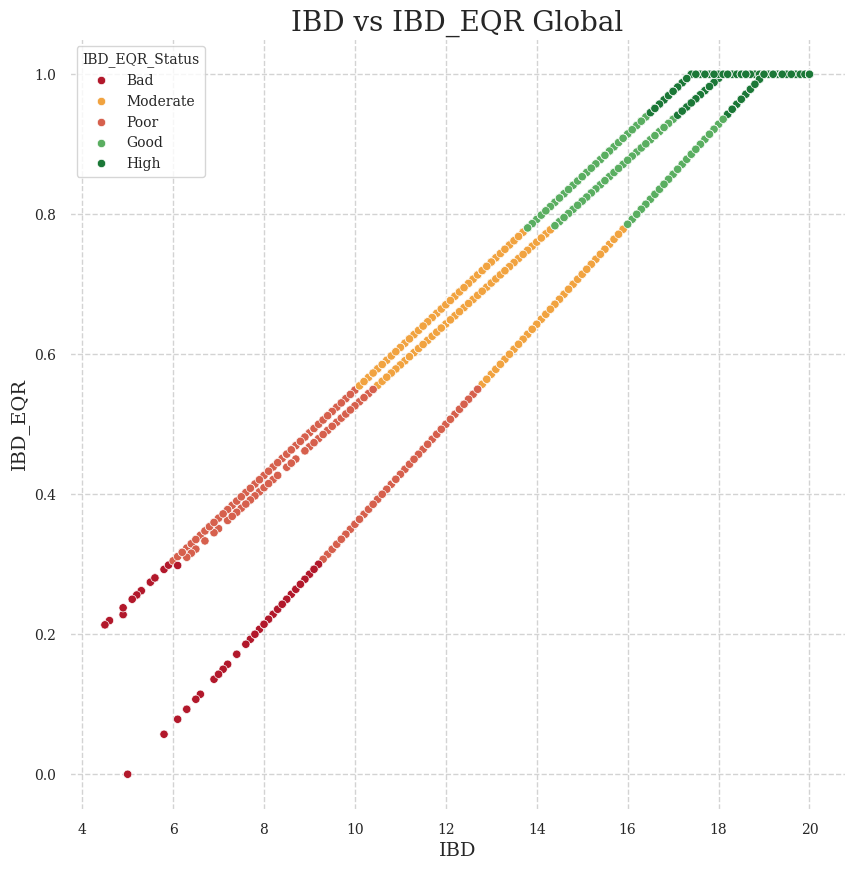

In [103]:
from scripts import style
style.mpl_apply()   

plt.figure(figsize=(10, 10))
sns.scatterplot(data=loire, x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', palette=palette)
plt.title("IBD vs IBD_EQR Global")
plt.show()

## HERlvl1Name

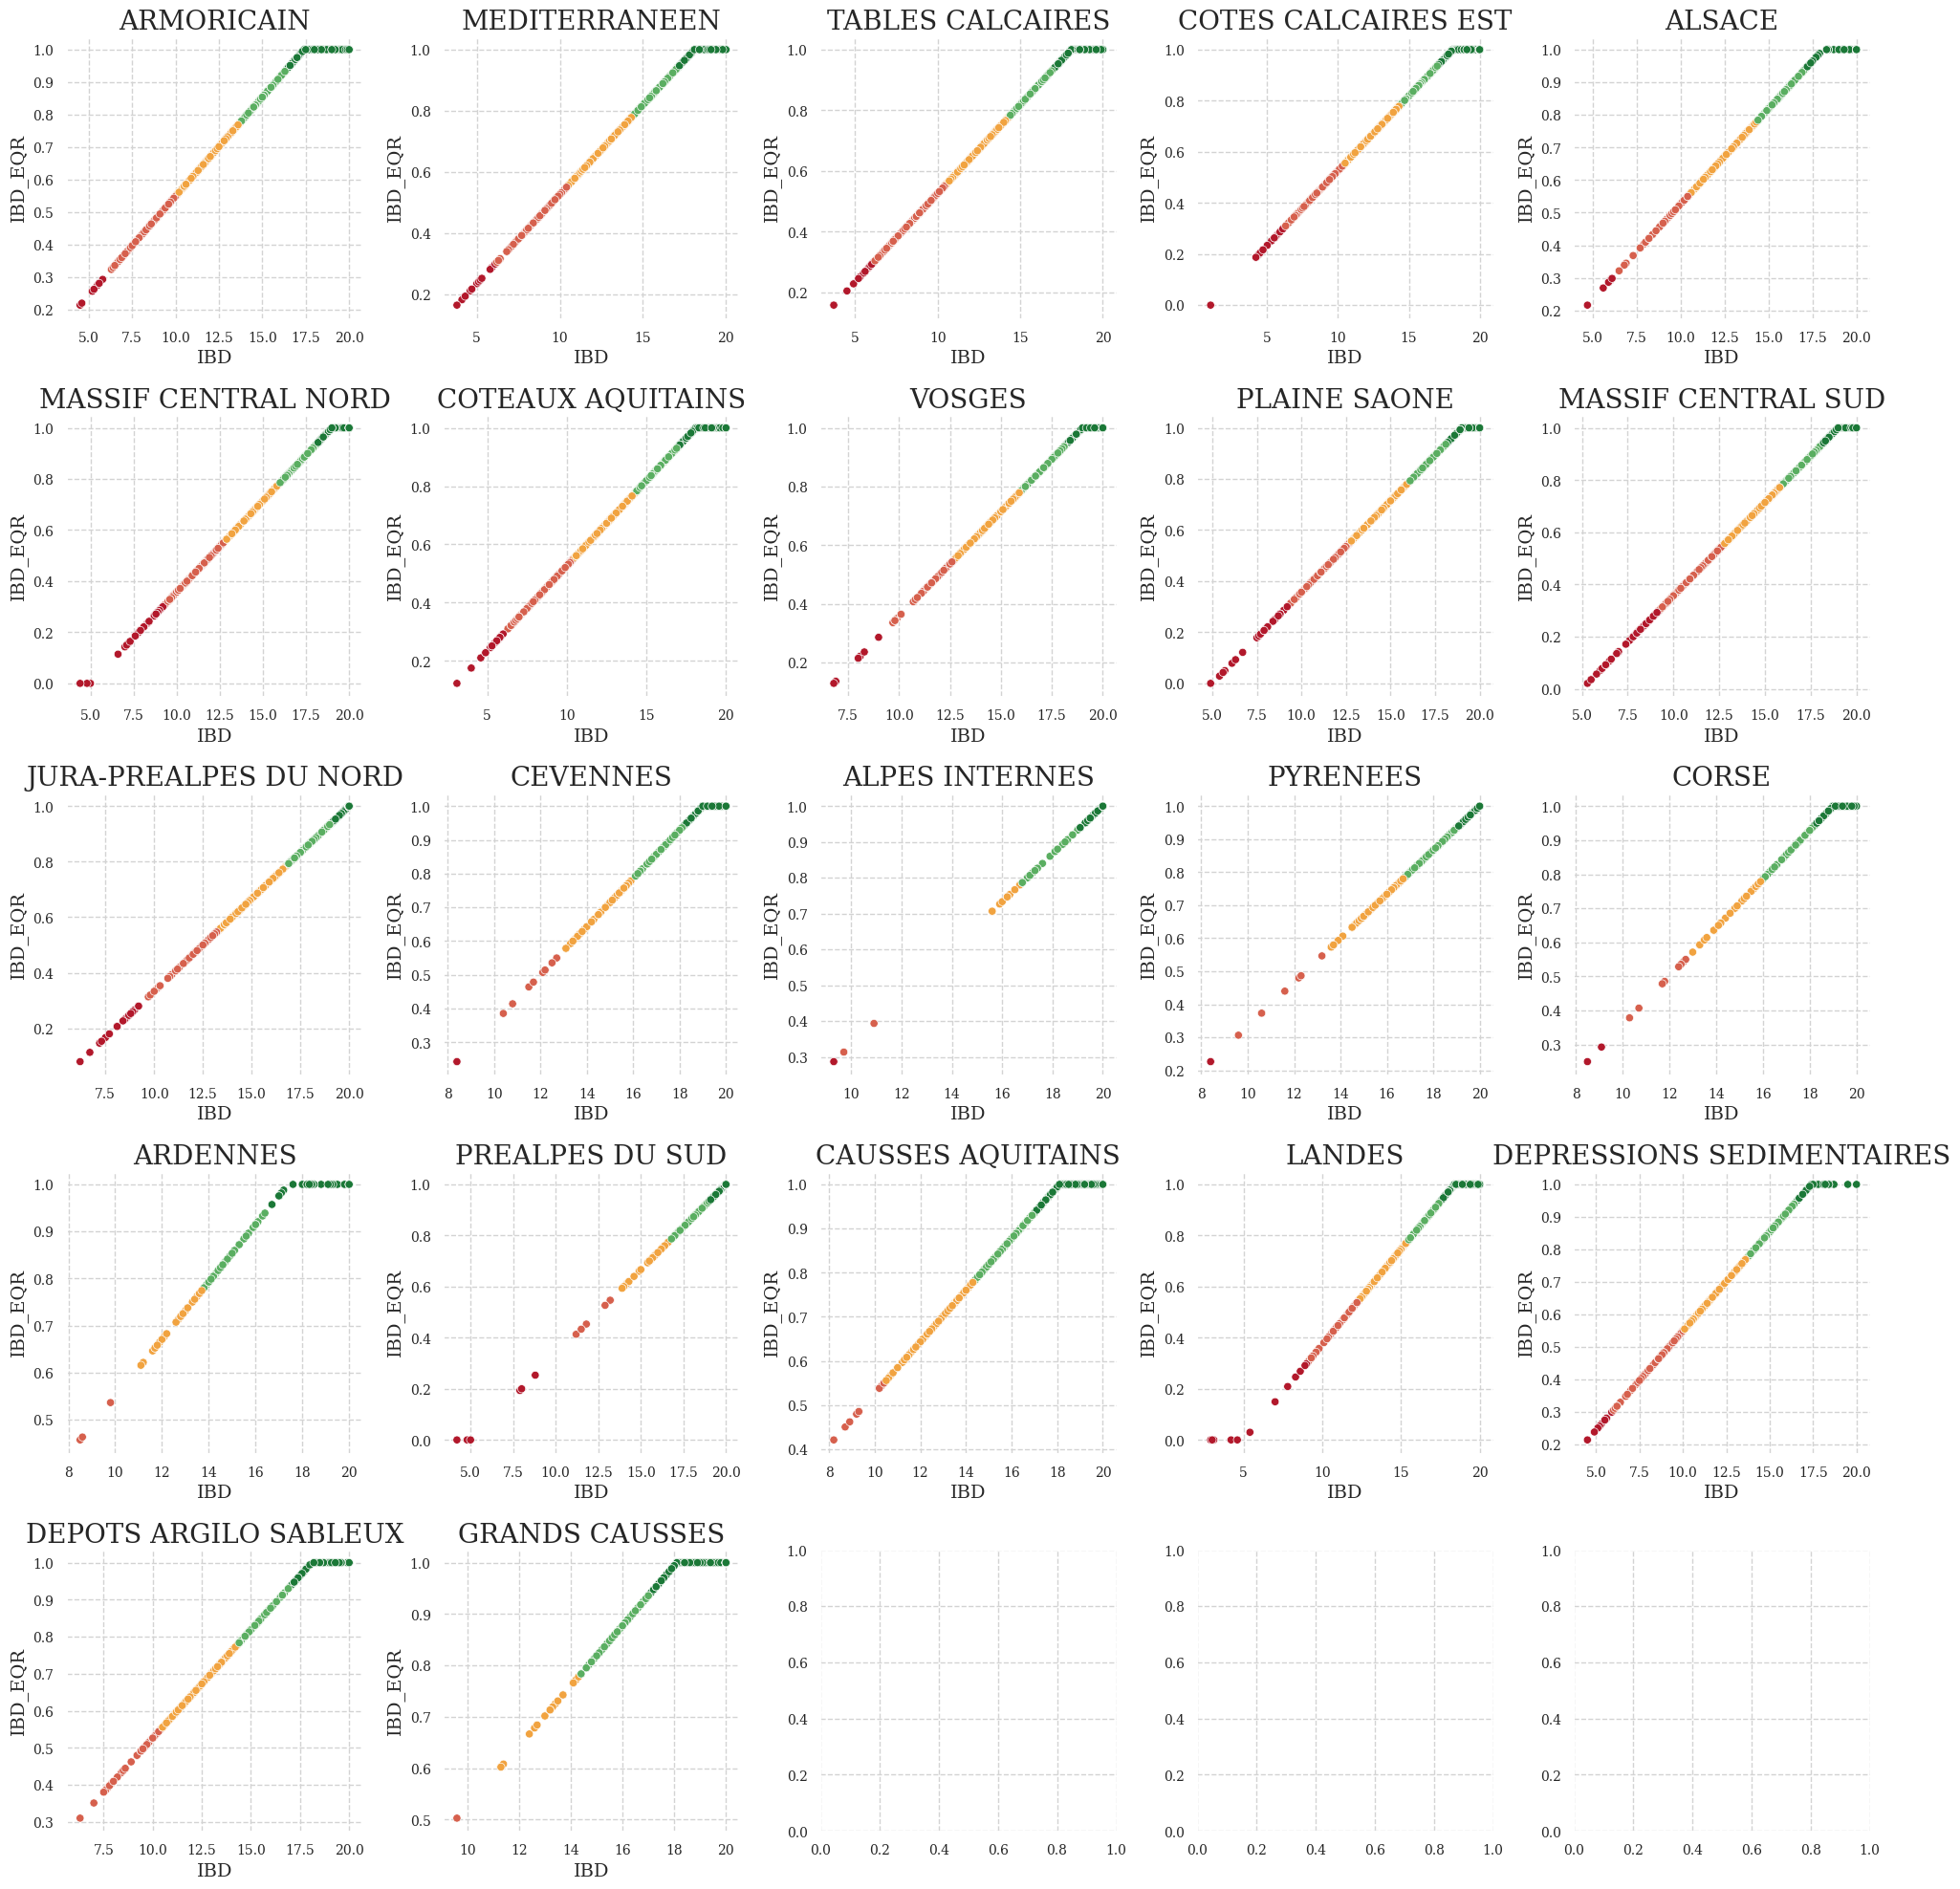

In [104]:
# subplot of 22 plots of each HERlvl1Name
herlvl1names = ibd_site["HERlvl1Name"].unique()
num_names = len(herlvl1names)
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
for i, name in enumerate(herlvl1names):
    ax = axs[i // 5, i % 5]
    sns.scatterplot(data=ibd_site[ibd_site["HERlvl1Name"] == name], x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', ax=ax, palette=palette)
    
    ax.set_title(name)
    ax.legend_.remove()

plt.tight_layout()
plt.show()

# THERE ARE 5 LINES FOR HERlvl1Name, BUT 22 REGIONS. WE CAN CONCAT SOME

## FOR AMORICAIN

In [105]:

ARMORICAIN = ibd_site[ibd_site["HERlvl1Name"] == "ARMORICAIN"]
others = ibd_site[ibd_site["HERlvl1Name"] != "ARMORICAIN"]
combined = pd.concat([ARMORICAIN, others])

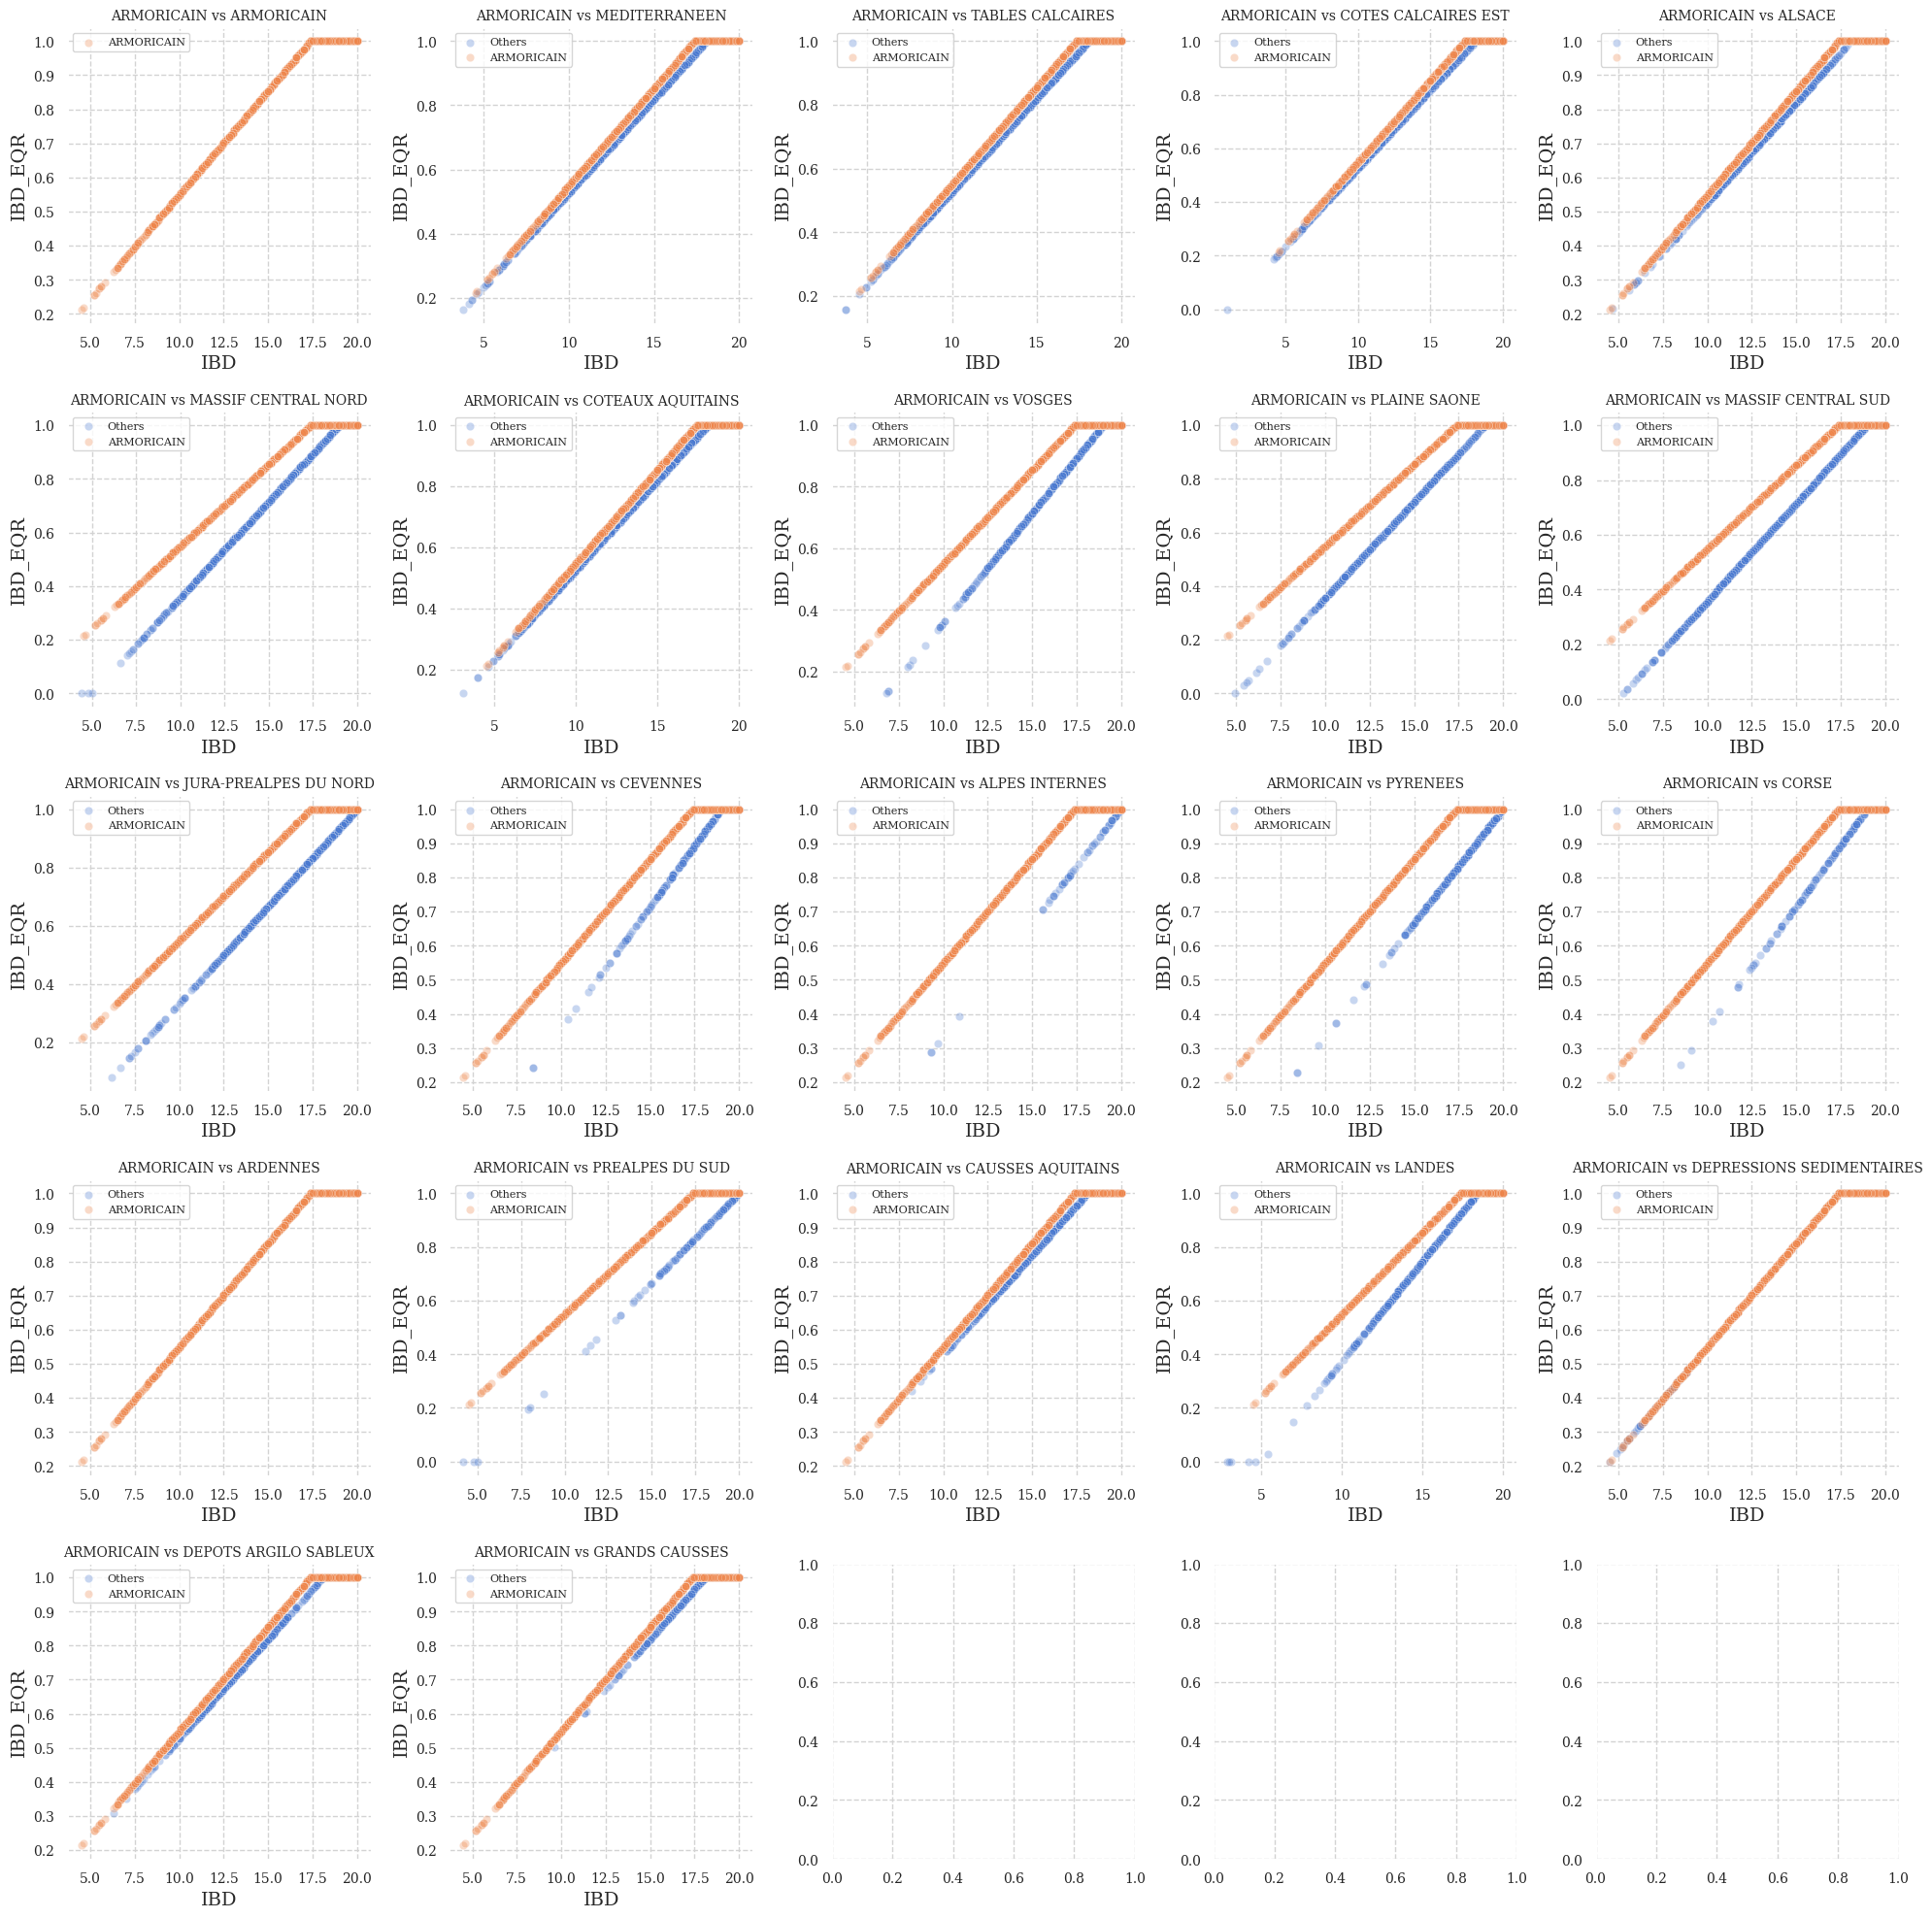

In [106]:
# subplot of 22 plots of each HERlvl1Name with ARMORICAIN highlighted
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20
, 20))
for i, name in enumerate(herlvl1names):
    ax = axs[i // 5, i % 5]
    sns.scatterplot(data=others[others["HERlvl1Name"] == name], x='IBD', y='IBD_EQR',  ax=ax, alpha=0.3, label='Others')
    sns.scatterplot(data=ARMORICAIN, x='IBD', y='IBD_EQR', ax=ax, alpha=0.3, label='ARMORICAIN')
    ax.set_title(f"ARMORICAIN vs {name}", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## AMORICAIN IS ONE WITH 'ARDENNES' AND 'DEPRESSONS SEDIMENTAIRES'

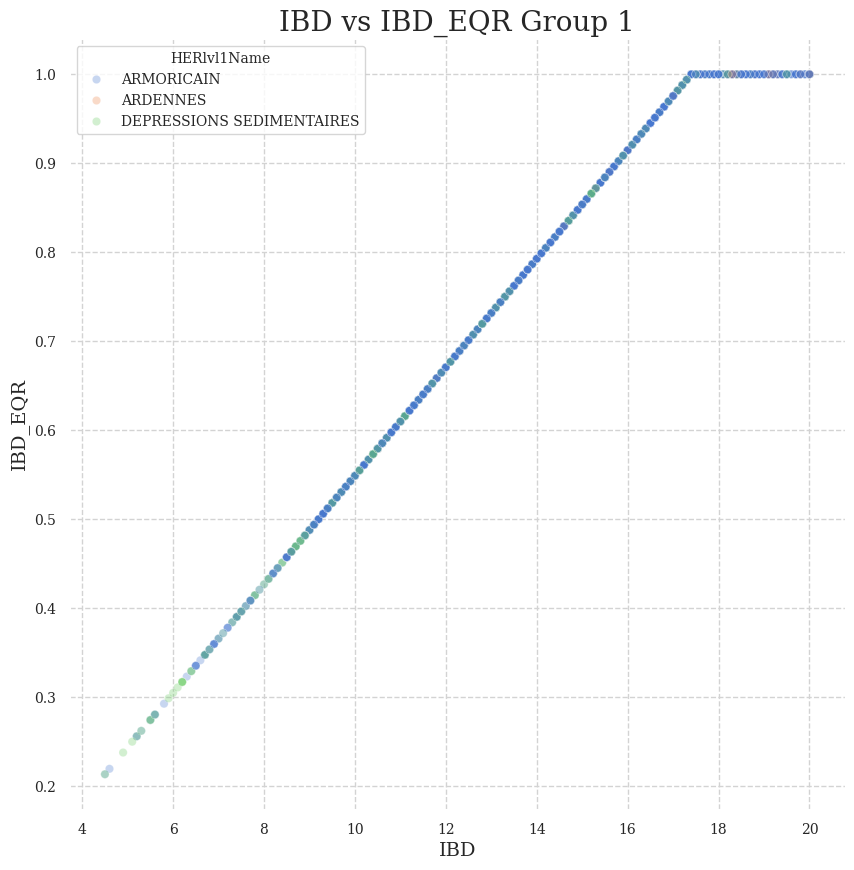

In [107]:
group1 = ["ARMORICAIN", "ARDENNES", "DEPRESSIONS SEDIMENTAIRES"]
DF1 = ibd_site[ibd_site["HERlvl1Name"].isin(group1)]
# PLOT THE IBD VS IBD_EQR FOR DF1
plt.figure(figsize=(10, 10))
sns.scatterplot(data=DF1, x='IBD', y='IBD_EQR', hue='HERlvl1Name', alpha=0.3)
plt.title("IBD vs IBD_EQR Group 1")
plt.show()

In [ ]:
#


# drop from the ibd_site the group1

ibd_site = ibd_site[~ibd_site["HERlvl1Name"].isin(group1)]

## Finding groups

In [109]:
def compare_region(REGION):
    region_name = ibd_site[ibd_site["HERlvl1Name"] == REGION]
    others = ibd_site[ibd_site["HERlvl1Name"] != REGION]
    combined = pd.concat([region_name, others])
    herlvl1names = others["HERlvl1Name"].unique()

    # subplot of 22 plots of each HERlvl1Name with ARMORICAIN highlighted
    fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(20, 20))
    for i, name in enumerate(herlvl1names):
        ax = axs[i // 5, i % 5]
        sns.scatterplot(data=others[others["HERlvl1Name"] == name], x='IBD', y='IBD_EQR',  ax=ax, alpha=0.3, label='Others')
        sns.scatterplot(data=region_name, x='IBD', y='IBD_EQR', ax=ax, alpha=0.3, label=REGION)
        ax.set_title(f"{REGION} vs {name}", fontsize=10)
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

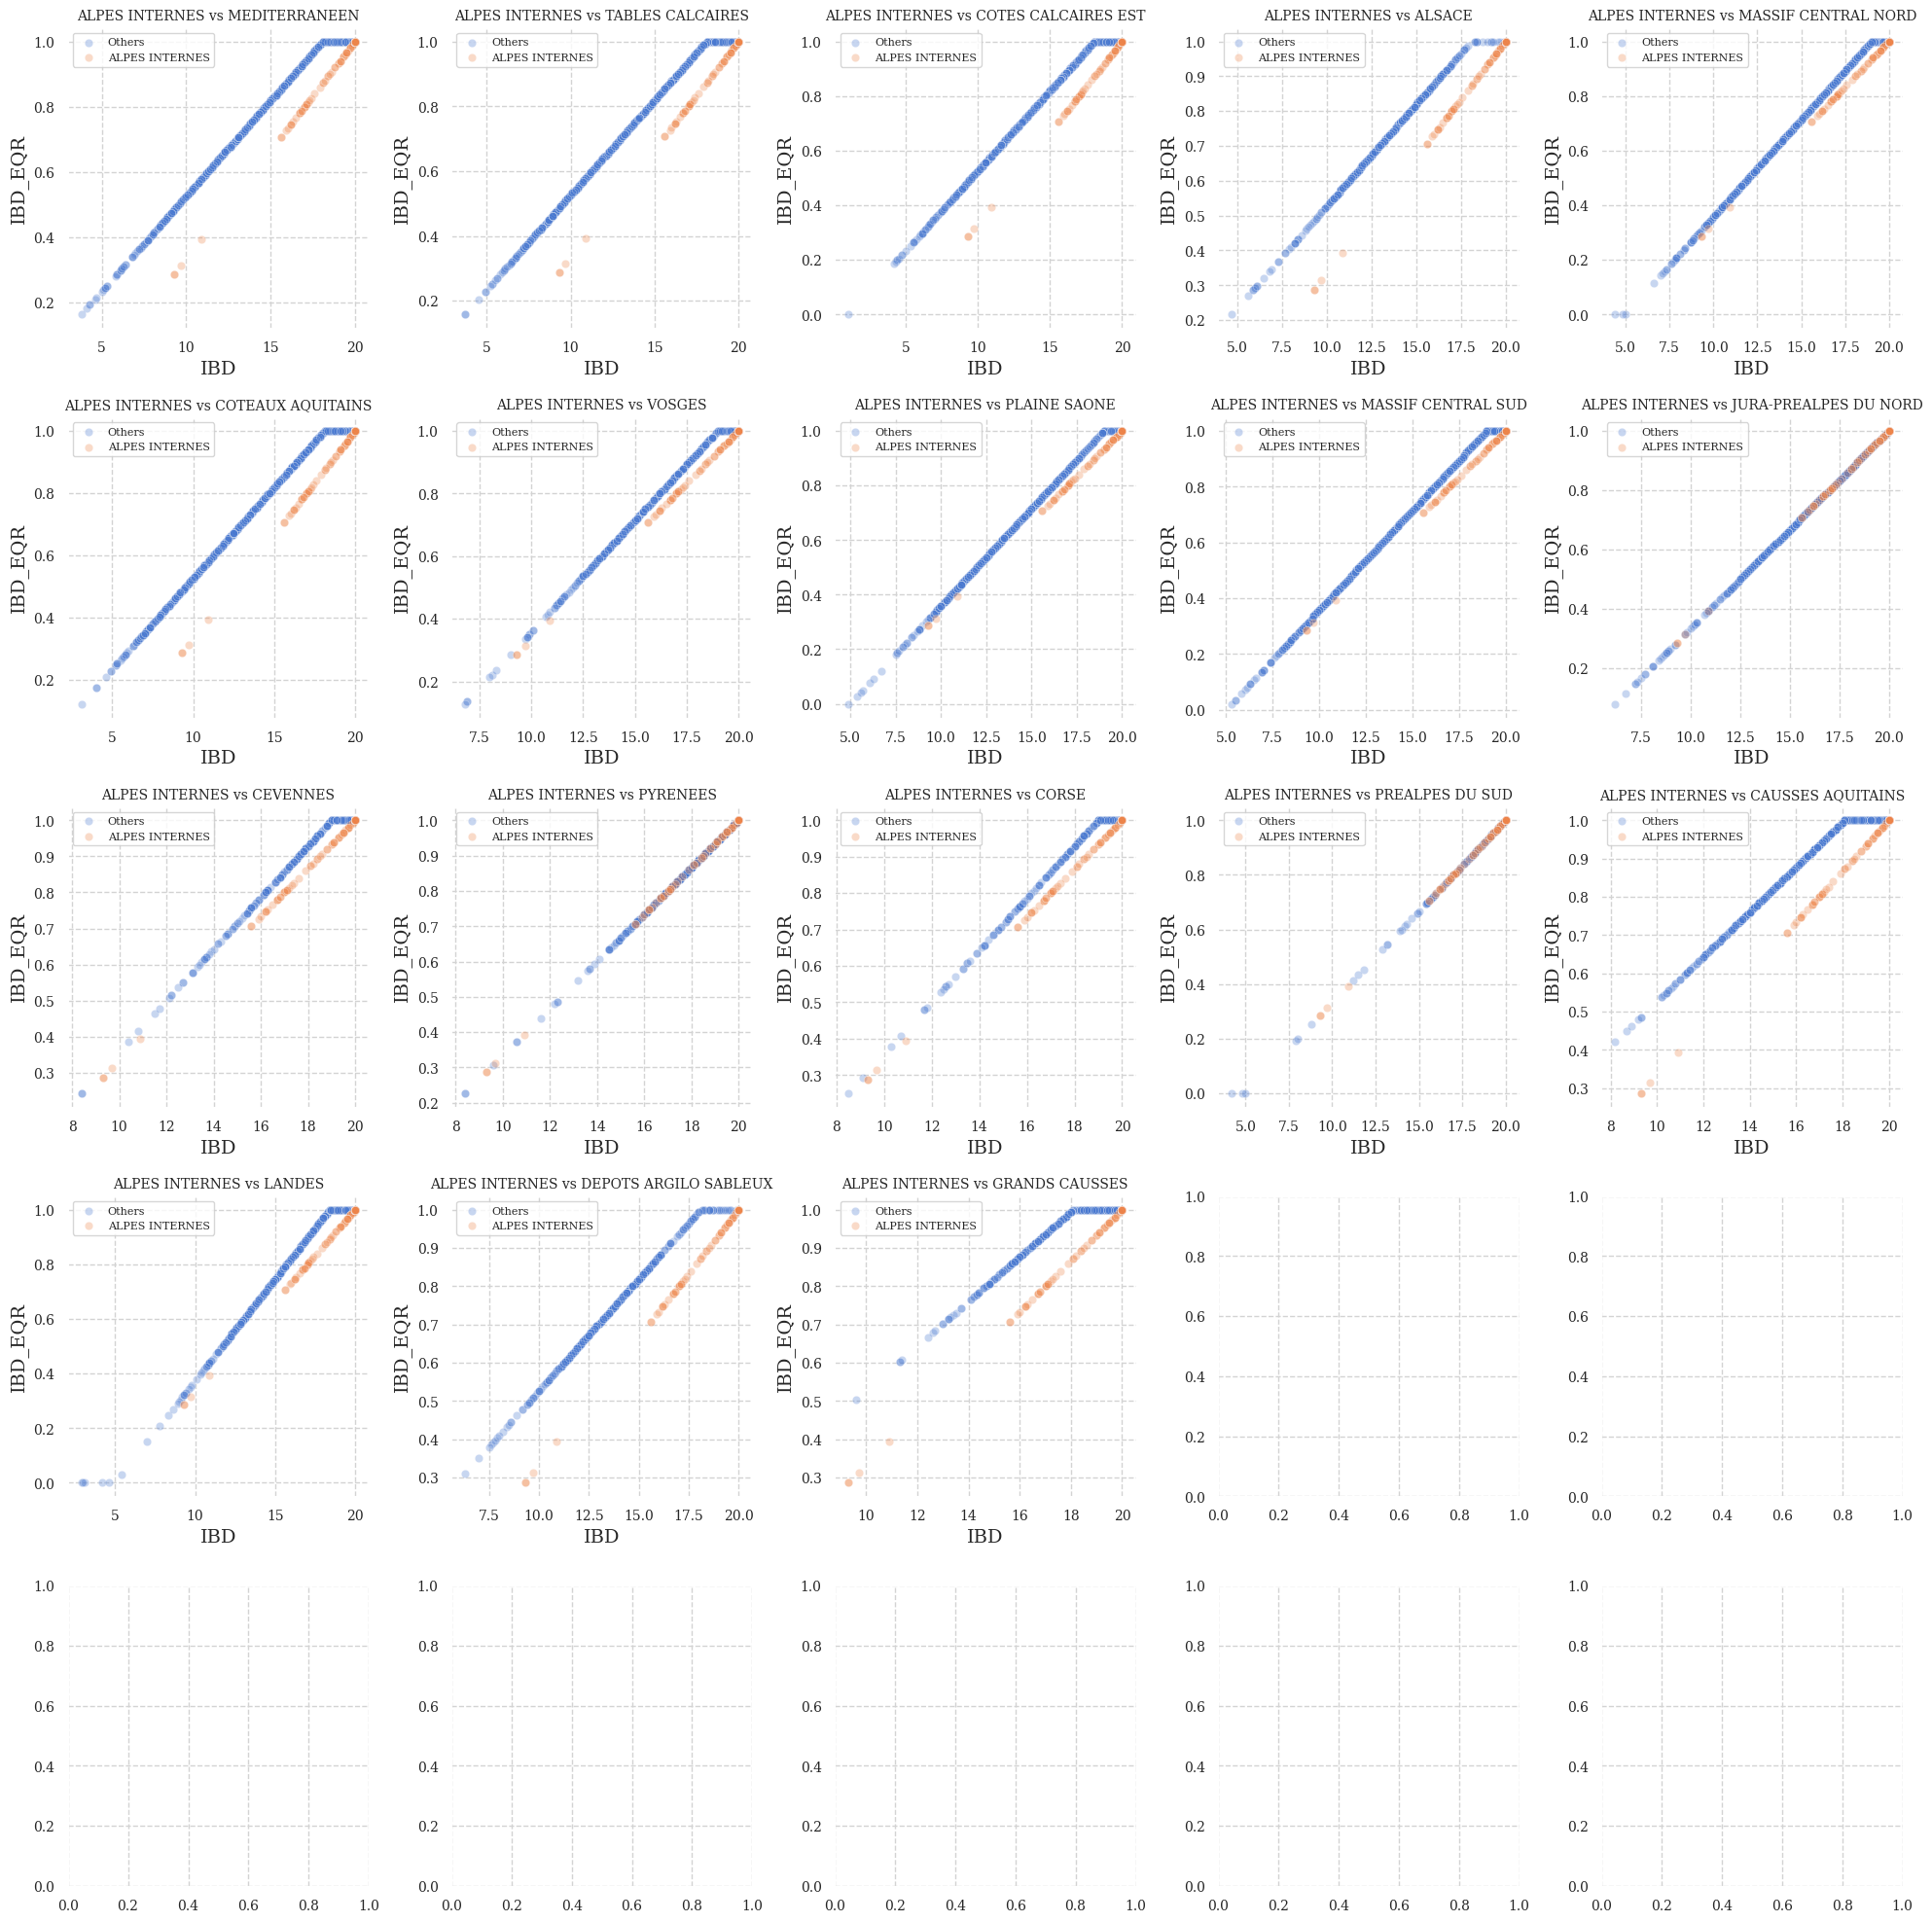

In [110]:
compare_region("ALPES INTERNES")

In [111]:
group2 = ["ALPES INTERNES", "PYRENEES", "PREALPES DU SUD", "JURA-PREALPES DU NORD"]
DF2 = ibd_site[ibd_site["HERlvl1Name"].isin(group2)]
ibd_site = ibd_site[~ibd_site["HERlvl1Name"].isin(group2)]

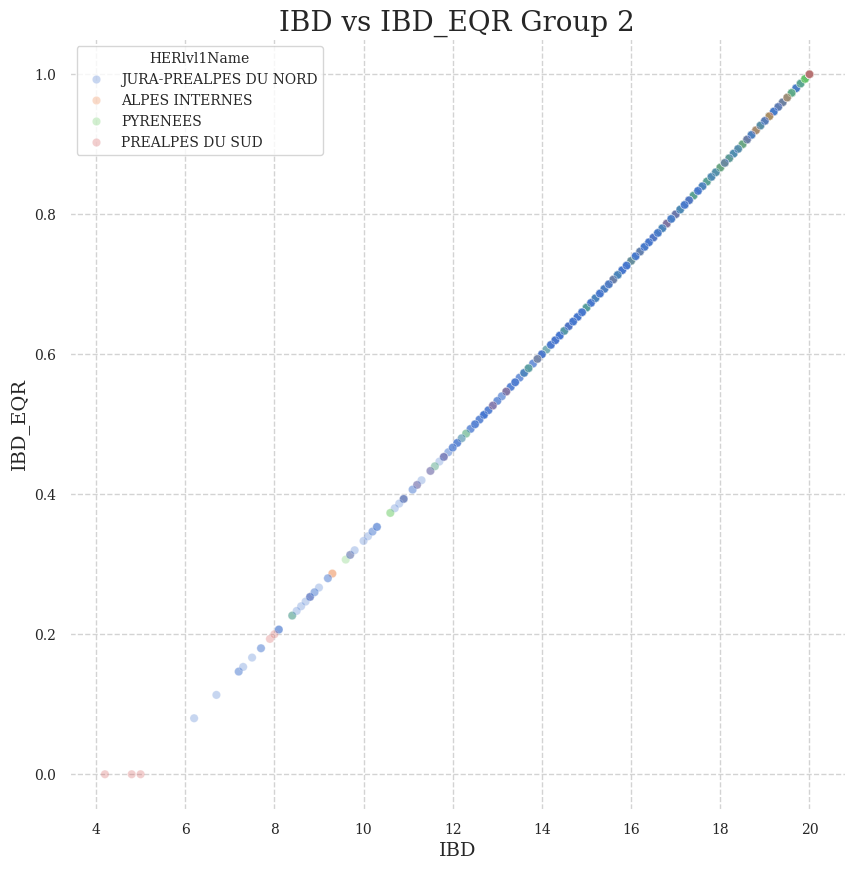

In [112]:
# PLOT THE IBD VS IBD_EQR FOR DF1
plt.figure(figsize=(10, 10))
sns.scatterplot(data=DF2, x='IBD', y='IBD_EQR', hue='HERlvl1Name', alpha=0.3)
plt.title("IBD vs IBD_EQR Group 2")
plt.show()

## group 3

In [113]:
# know the HERlvl1Name that remains
ibd_site["HERlvl1Name"].unique()

array(['MEDITERRANEEN', 'TABLES CALCAIRES', 'COTES CALCAIRES EST',
       'ALSACE', 'MASSIF CENTRAL NORD', 'COTEAUX AQUITAINS', 'VOSGES',
       'PLAINE SAONE', 'MASSIF CENTRAL SUD', 'CEVENNES', 'CORSE',
       'CAUSSES AQUITAINS', 'LANDES', 'DEPOTS ARGILO SABLEUX',
       'GRANDS CAUSSES'], dtype=object)

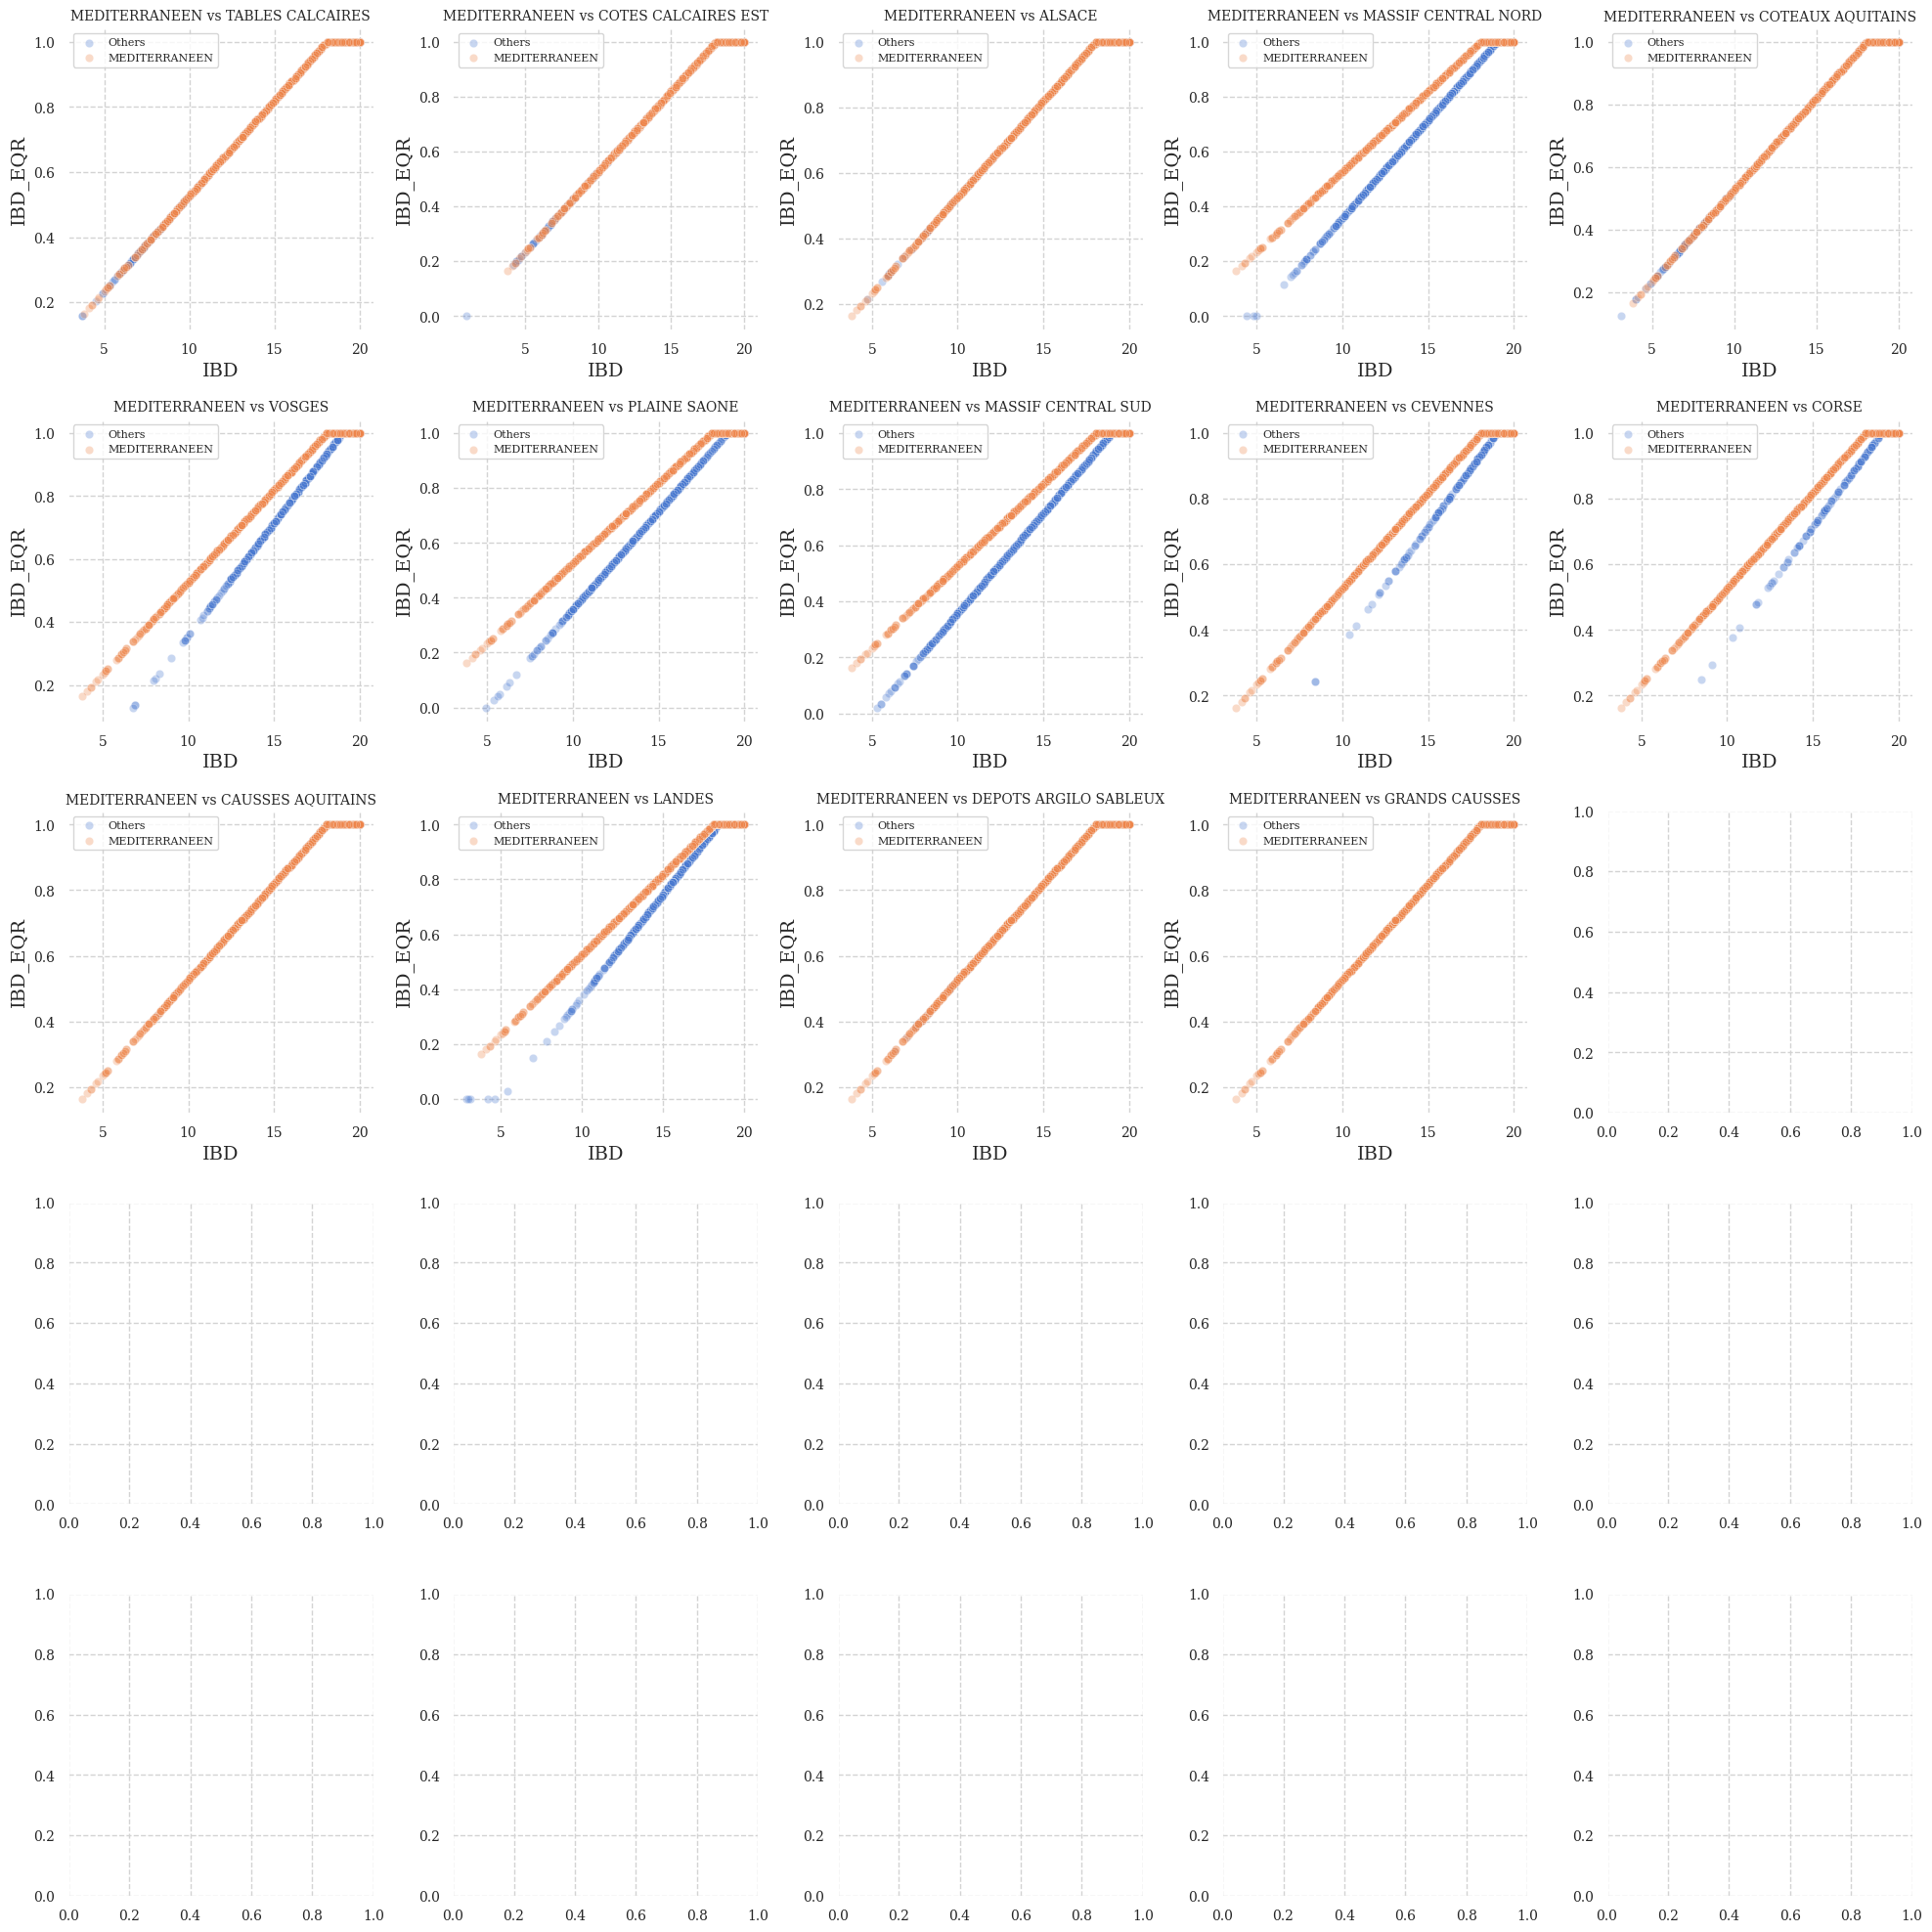

In [114]:
compare_region("MEDITERRANEEN")

In [140]:
# gropp 3
group3 = ["MEDITERRANEEN", "COTES CALCAIRES EST", "TABLES CALCAIRES", "ALSACE", "COTEAUX AQUITAINS", "CAUSSES AQUITAINS", "DEPOTS ARGILO SABLEUX", "GRANDS CAUSSES"]
DF3 = df_copy[df_copy["HERlvl1Name"].isin(group3)]

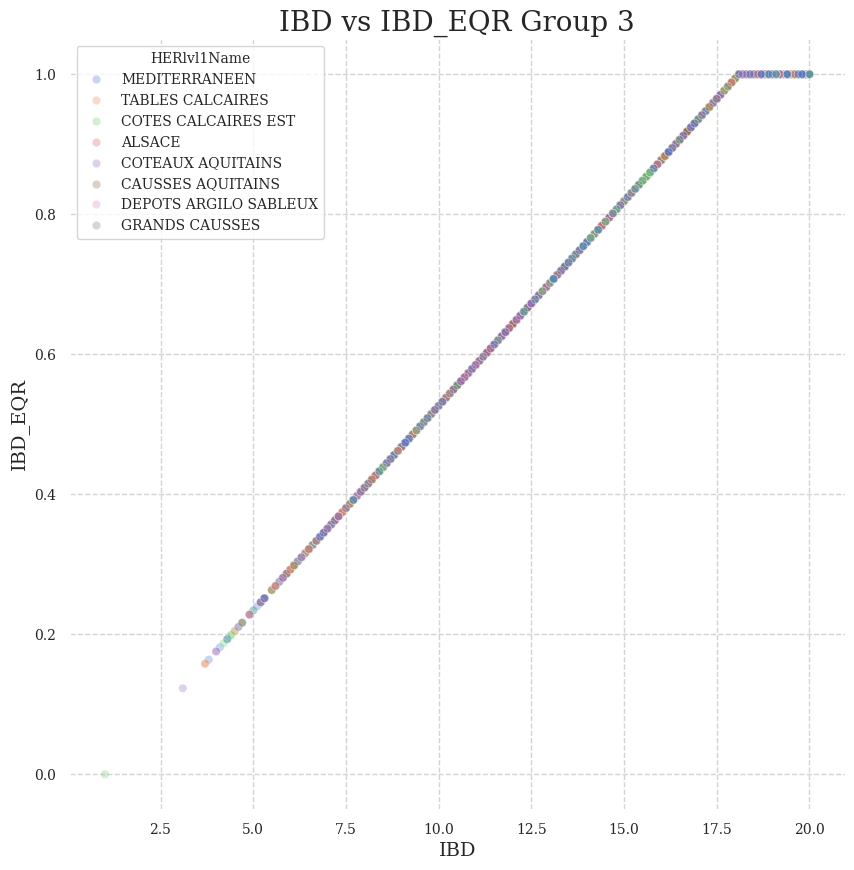

In [142]:
# PLOT THE IBD VS IBD_EQR FOR DF1
plt.figure(figsize=(10, 10))
sns.scatterplot(data=DF3, x='IBD', y='IBD_EQR', hue='HERlvl1Name', alpha=0.3)
plt.title("IBD vs IBD_EQR Group 3")
plt.show()

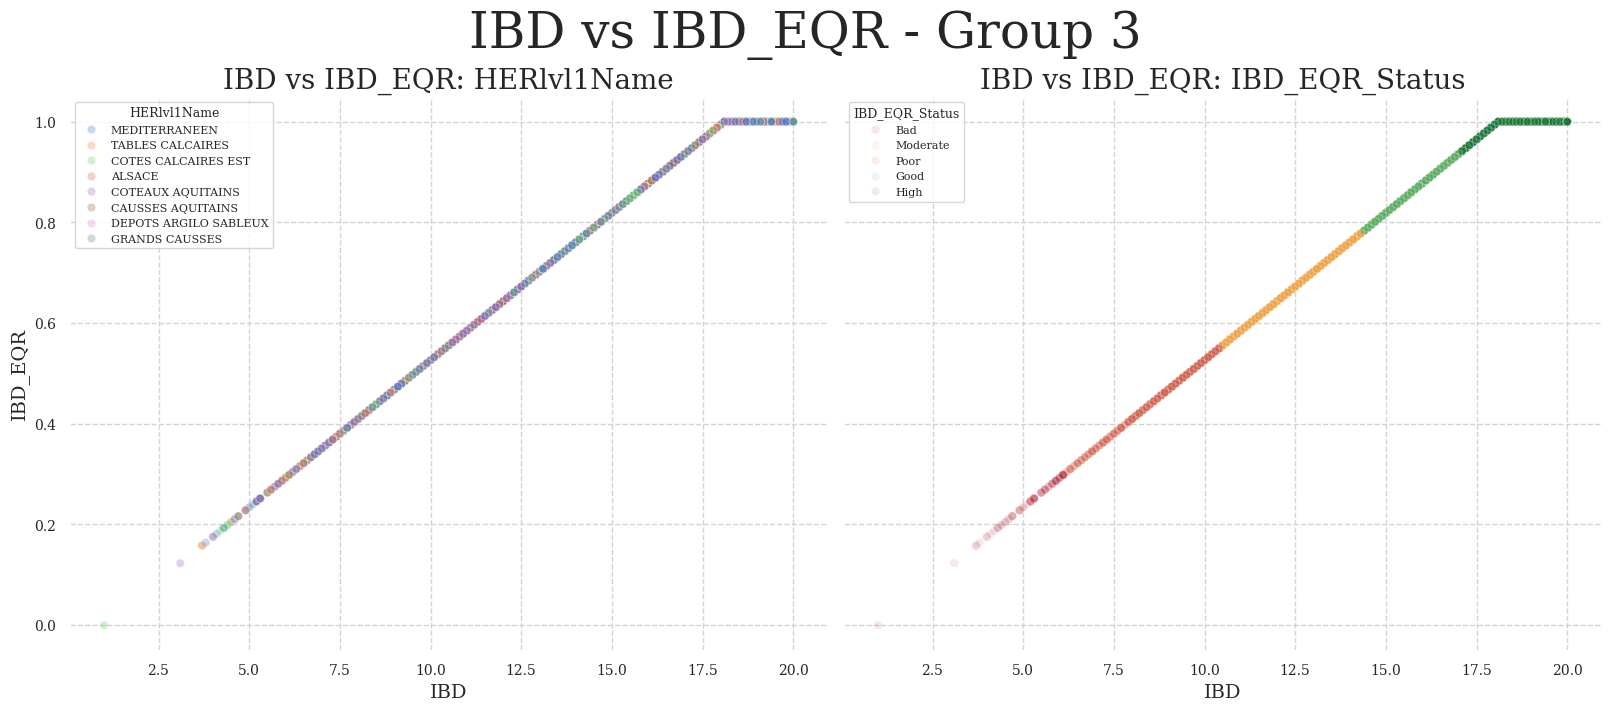

In [143]:
def plot_group(DF, title):
    # two side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True, constrained_layout=True)

    # Title for the entire figure
    fig.suptitle(title, fontsize=36)

    # left: hue by HERlvl1Name
    sns.scatterplot(data=DF, x='IBD', y='IBD_EQR', hue='HERlvl1Name', alpha=0.3, ax=axes[0])
    axes[0].set_title("IBD vs IBD_EQR: HERlvl1Name")
    axes[0].set_xlabel("IBD")
    axes[0].set_ylabel("IBD_EQR")
    axes[0].legend(title="HERlvl1Name", fontsize=8, title_fontsize=9, loc="best")

    # right: hue by IBD_EQR_Status
    sns.scatterplot(data=DF, x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', alpha=0.1, palette=palette, ax=axes[1])
    axes[1].set_title("IBD vs IBD_EQR: IBD_EQR_Status")
    axes[1].set_xlabel("IBD")
    axes[1].set_ylabel("IBD_EQR")
    axes[1].legend(title="IBD_EQR_Status", fontsize=8, title_fontsize=9, loc="best")

    plt.savefig(f"visualizations/Groups_IBD/{title}.png", dpi=300)
    plt.show()


plot_group(DF3, "IBD vs IBD_EQR - Group 3")


In [118]:
ibd_site = ibd_site[~ibd_site["HERlvl1Name"].isin(group3)]

## GROUP 4

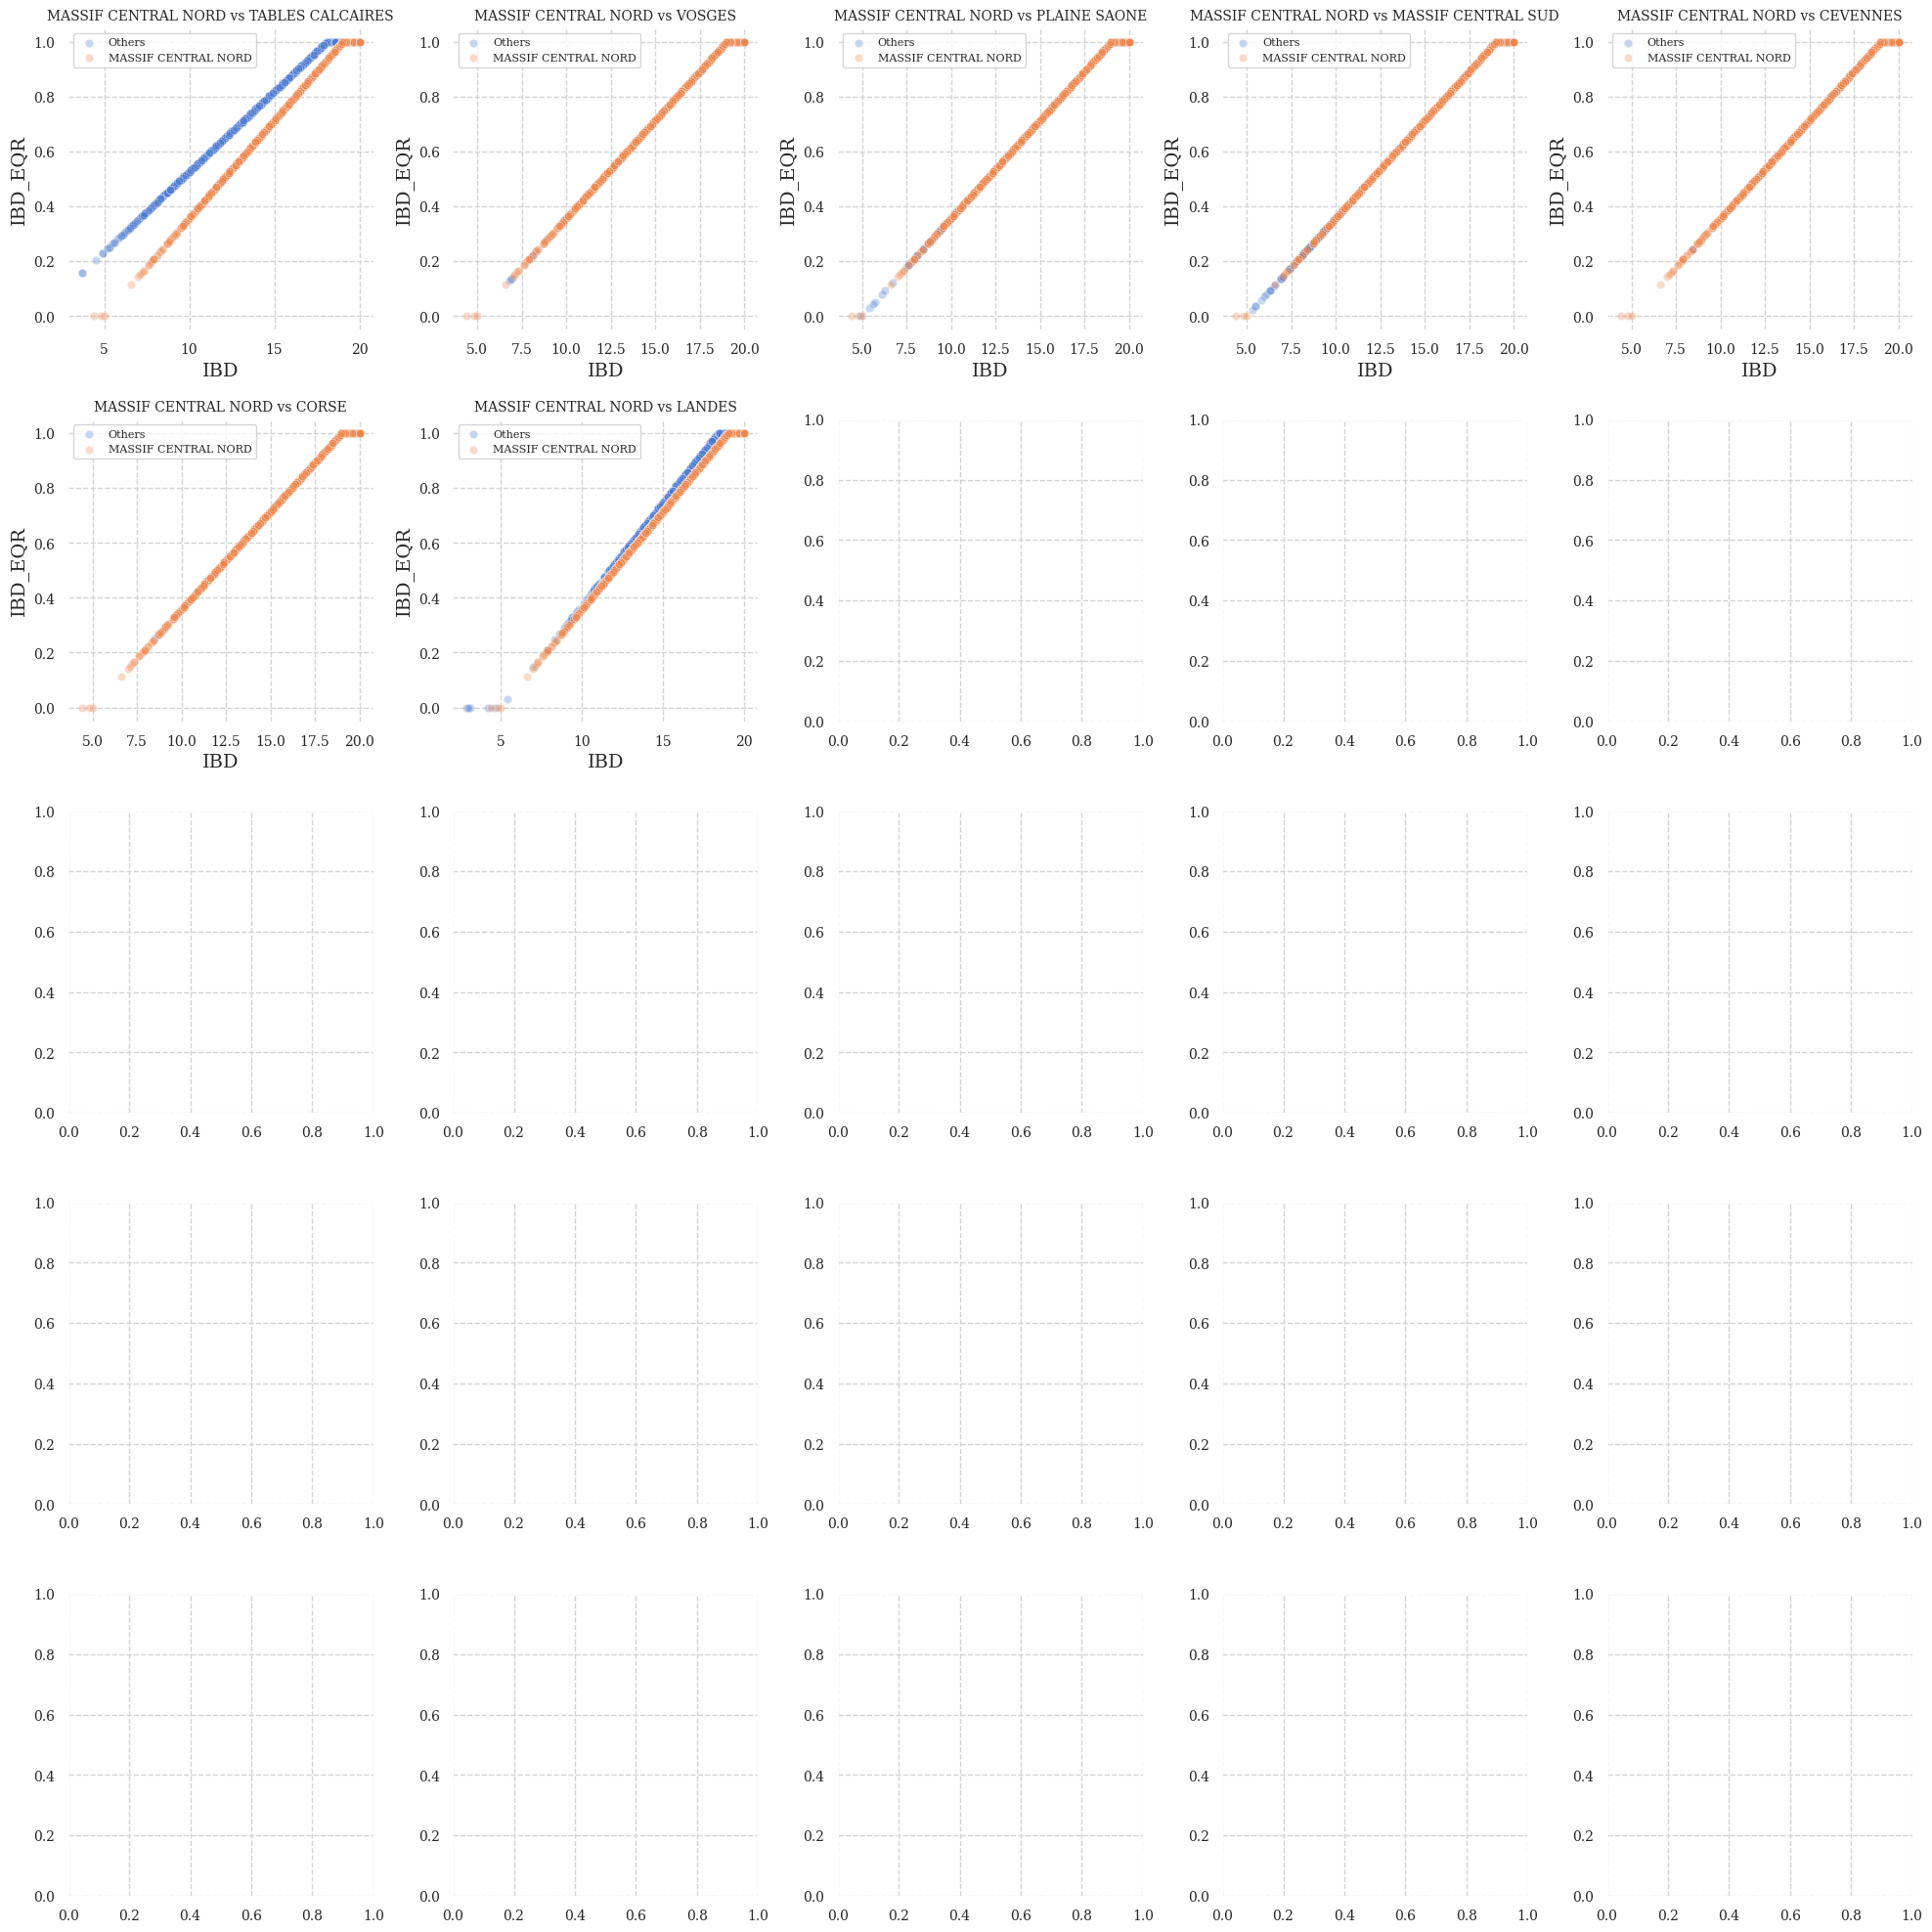

In [119]:
compare_region("MASSIF CENTRAL NORD")

In [120]:
# know HERlvl1Name that remains
ibd_site["HERlvl1Name"].unique()

array(['TABLES CALCAIRES', 'MASSIF CENTRAL NORD', 'VOSGES',
       'PLAINE SAONE', 'MASSIF CENTRAL SUD', 'CEVENNES', 'CORSE',
       'LANDES'], dtype=object)

In [121]:
group4 = ["MASSIF CENTRAL NORD", "VOSGES", "PLAINE SAONE", "MASSIF CENTRAL SUD", "CEVENNES", "CORSE"]
DF4 = ibd_site[ibd_site["HERlvl1Name"].isin(group4)]

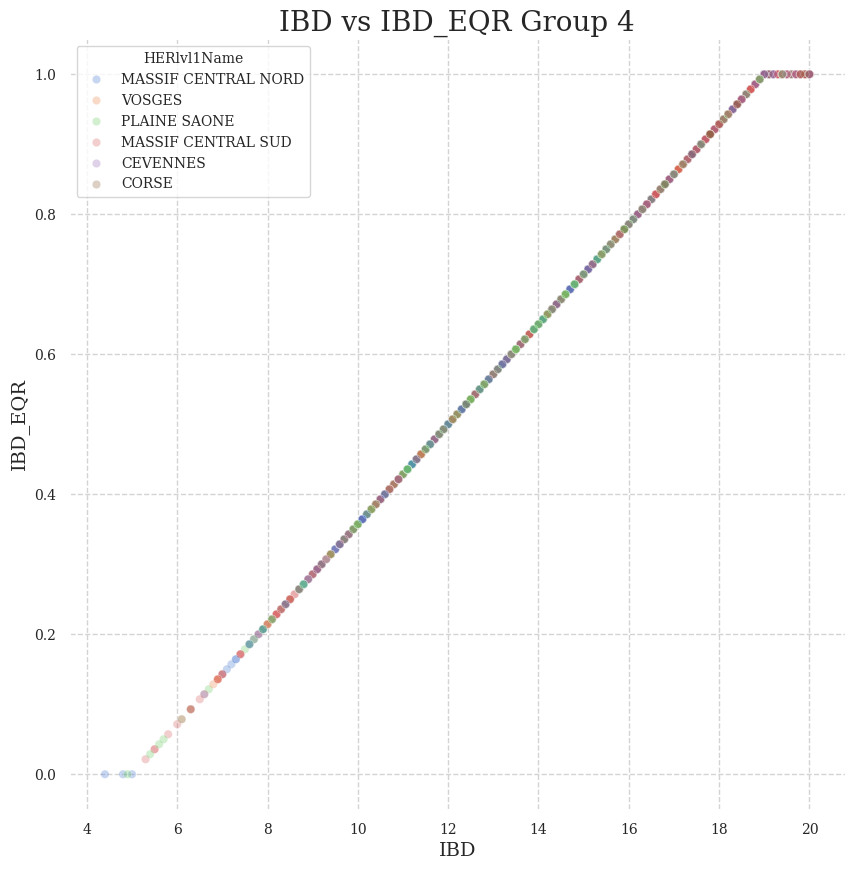

In [122]:
# PLOT THE IBD VS IBD_EQR FOR DF1
plt.figure(figsize=(10, 10))
sns.scatterplot(data=DF4, x='IBD', y='IBD_EQR', hue='HERlvl1Name', alpha=0.3)
plt.title("IBD vs IBD_EQR Group 4")
plt.show()

In [123]:
ibd_site = ibd_site[~ibd_site["HERlvl1Name"].isin(group4)]

# Group 5

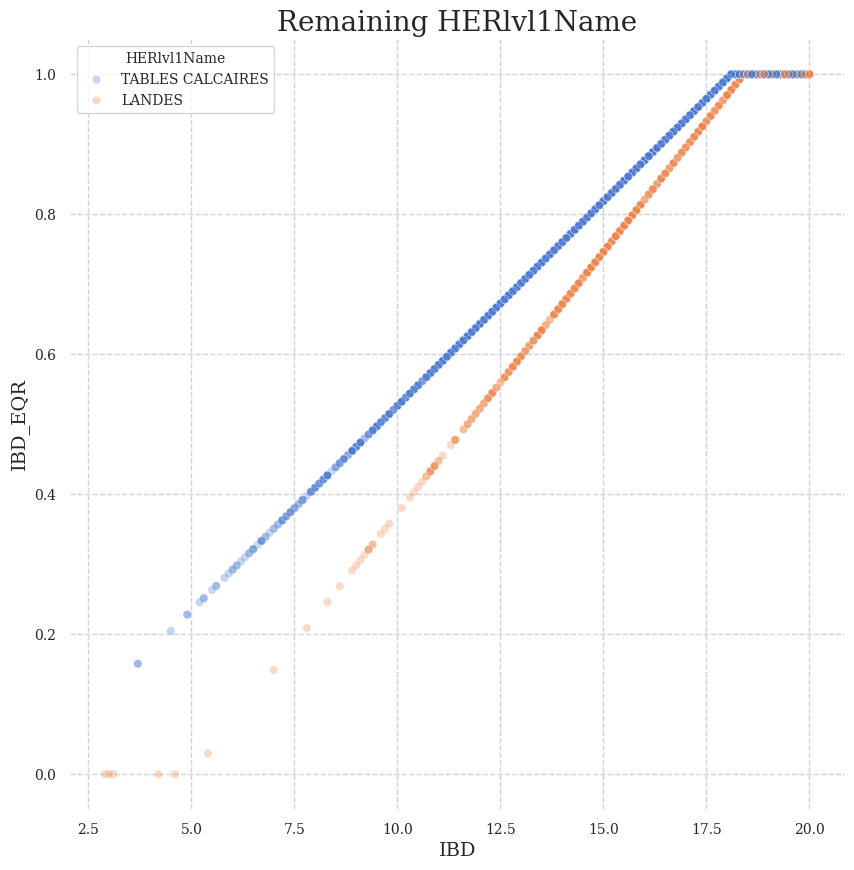

In [124]:
# PLOT THE IBD VS IBD_EQR FOR DF1
plt.figure(figsize=(10, 10))
sns.scatterplot(data=ibd_site, x='IBD', y='IBD_EQR', hue='HERlvl1Name', alpha=0.3)
plt.title("Remaining HERlvl1Name")
plt.show()

In [ ]:
group5 = ['LANDES']
DF5 = df_copy[df_copy["HERlvl1Name"].isin(group5)]
ibd_site = ibd_site[~ibd_site["HERlvl1Name"].isin(group5)]

# Visualizations

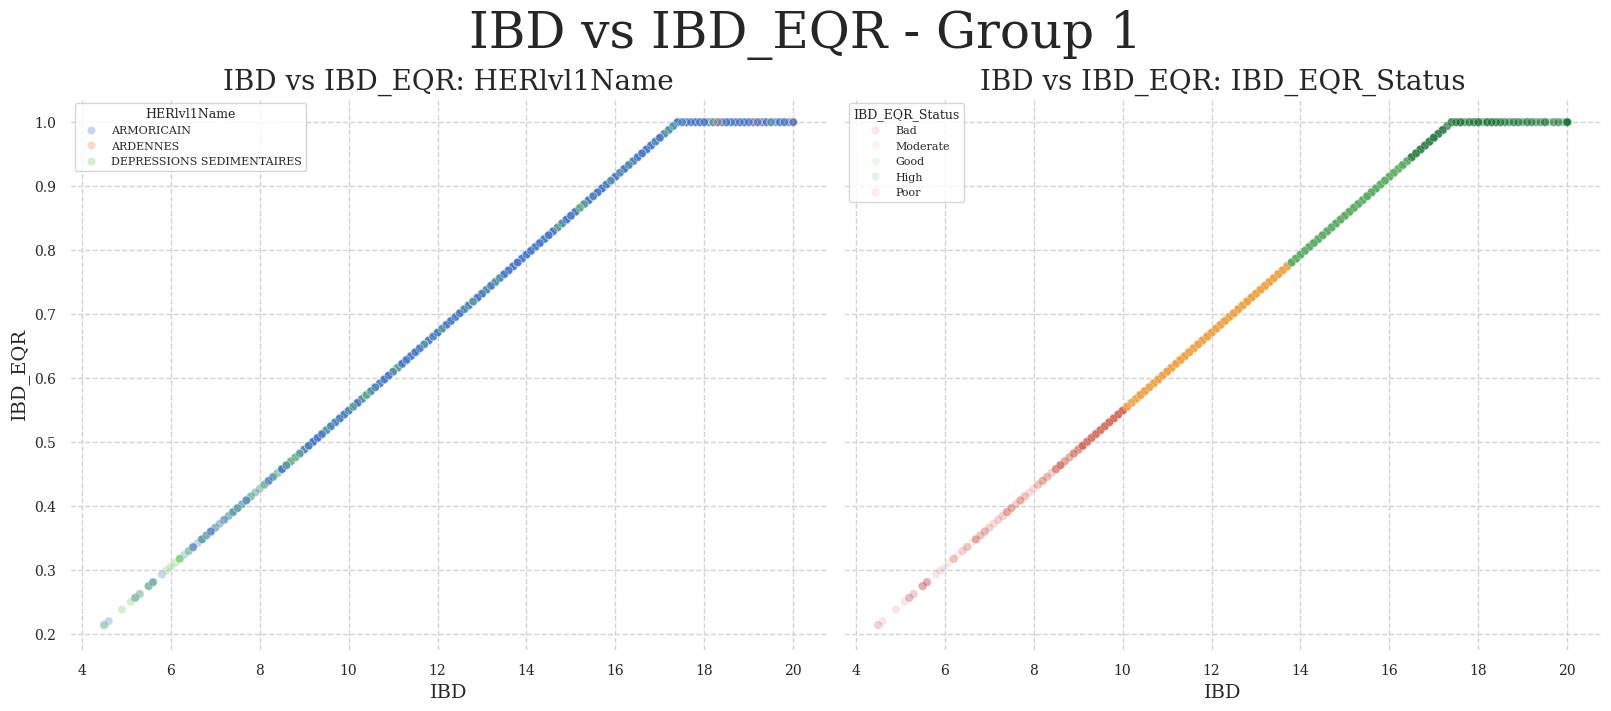

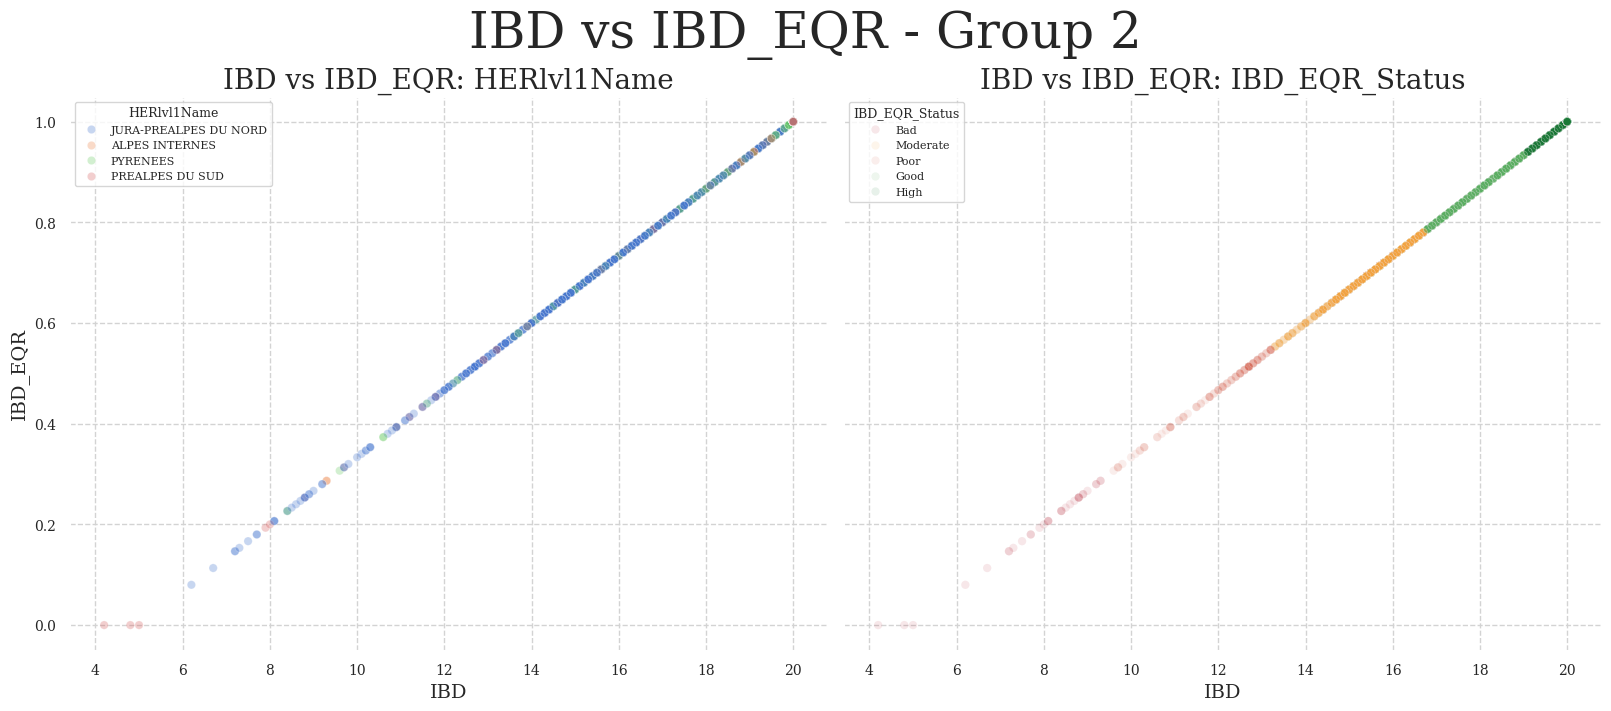

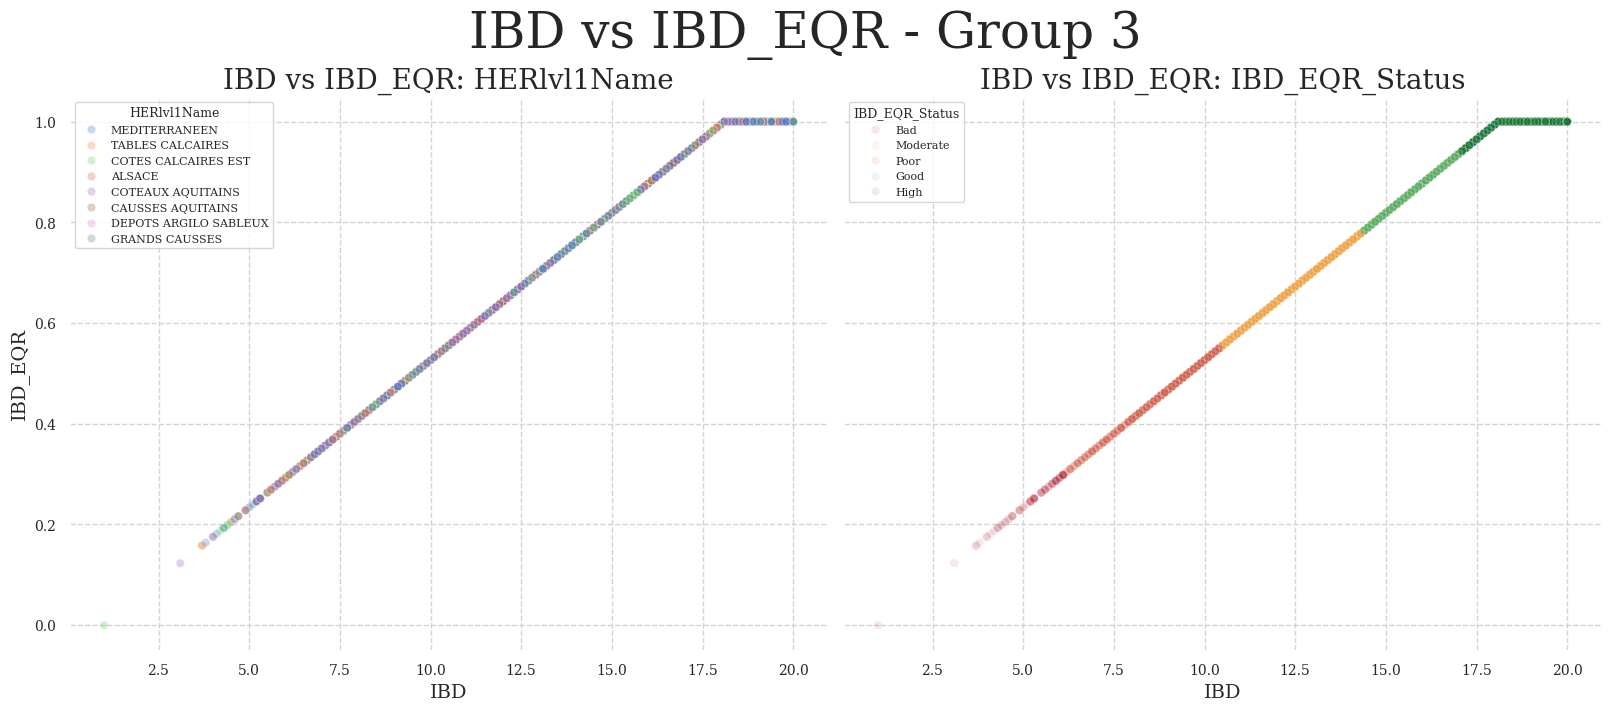

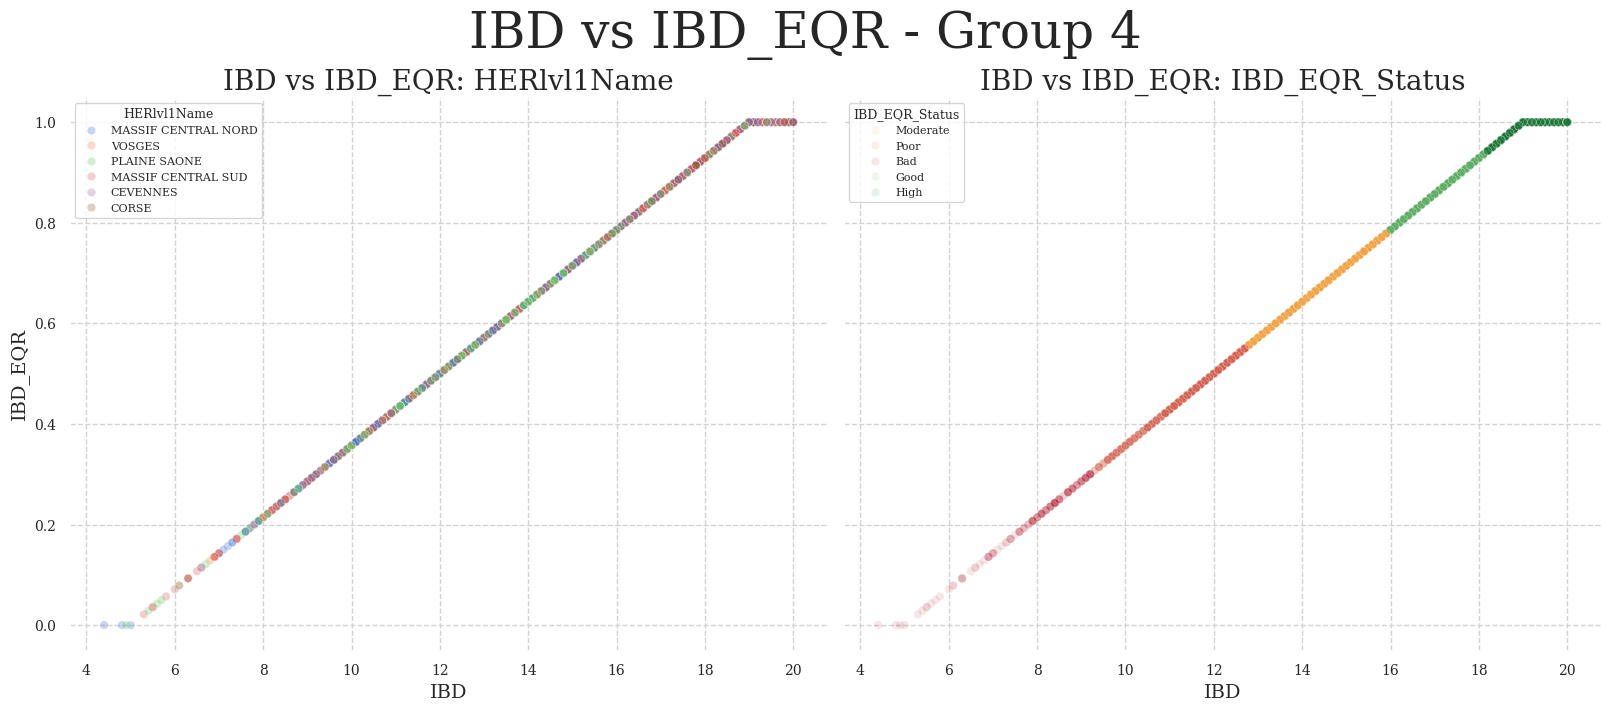

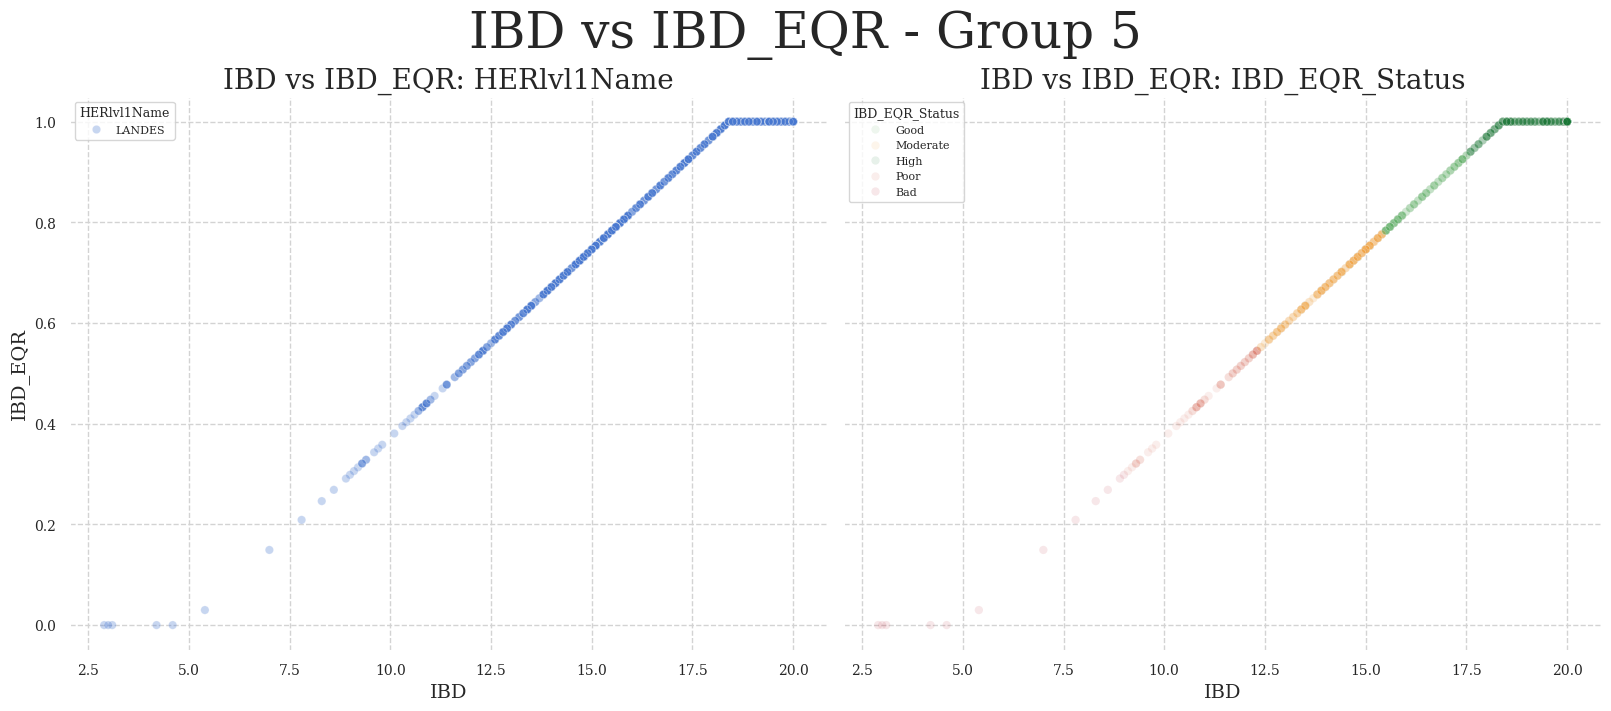

In [145]:
plot_group(DF1, "IBD vs IBD_EQR - Group 1")
plot_group(DF2, "IBD vs IBD_EQR - Group 2")
plot_group(DF3, "IBD vs IBD_EQR - Group 3")
plot_group(DF4, "IBD vs IBD_EQR - Group 4")
plot_group(DF5, "IBD vs IBD_EQR - Group 5")

In [ ]:
df_copy["Group"] = df_copy.apply(lambda row: 'Group 1' if row["HERlvl1Name"] in group1 else np.nan, axis=1)
df_copy["Group"] = df_copy.apply(lambda row: 'Group 2' if row["HERlvl1Name"] in group2 else row["Group"], axis=1)
df_copy["Group"] = df_copy.apply(lambda row: 'Group 3' if row["HERlvl1Name"] in group3 else row["Group"], axis=1)
df_copy["Group"] = df_copy.apply(lambda row: 'Group 4' if row["HERlvl1Name"] in group4 else row["Group"], axis=1)
df_copy["Group"] = df_copy.apply(lambda row: 'Group 5' if row["HERlvl1Name"] in group5 else row["Group"], axis=1)

In [147]:
df_copy

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize,Group
0,S04319000,5.2,0.256098,Bad,S04319000,249988.70,6870104.00,Loire-Bretagne,22,12,ARMORICAIN,118,MA-cotes du nord,0.0,None,Group 1
1,S06172100,6.1,0.298246,Bad,S06172100,701920.00,6179025.00,Rhône-Méditerranée,66,6,MEDITERRANEEN,105,Plaine mediterraneenne,2.0,G,Group 3
2,S03255920,3.7,0.157895,Bad,S03255920,392127.43,6919543.37,Seine-Normandie,50,9,TABLES CALCAIRES,37,Cotentin est,2.0,M,Group 3
3,S04064720,4.9,0.228070,Bad,S04064720,640744.79,6659017.17,Loire-Bretagne,18,9,TABLES CALCAIRES,41,Tables calcaires Sud Loire,0.0,TG,Group 3
4,S05001500,5.3,0.251462,Bad,S05001500,394250.00,6546400.00,Adour-Garonne,17,9,TABLES CALCAIRES,97,TC - Charentes Poitou,0.0,None,Group 3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43778,S06165700,6.8,0.339181,Poor,S06165700,902440.00,6292314.00,Rhône-Méditerranée,84,6,MEDITERRANEEN,56,Collines de Basse Provence,208.0,P,Group 3
43779,S06440770,15.3,0.836257,Good,S06440770,903503.00,6689363.00,Rhône-Méditerranée,70,10,COTES CALCAIRES EST,75,Collines de Haute-Saone,200.0,TP,Group 3
43780,S06710030,18.4,1.000000,High,S06710030,931683.00,6317300.00,Rhône-Méditerranée,04,6,MEDITERRANEEN,56,Collines de Basse Provence,346.0,P,Group 3
43781,S06036970,14.5,0.678571,Moderate,S06036970,851727.00,6655572.00,Rhône-Méditerranée,21,15,PLAINE SAONE,81,Plaine de Bourgogne,180.0,P,Group 4


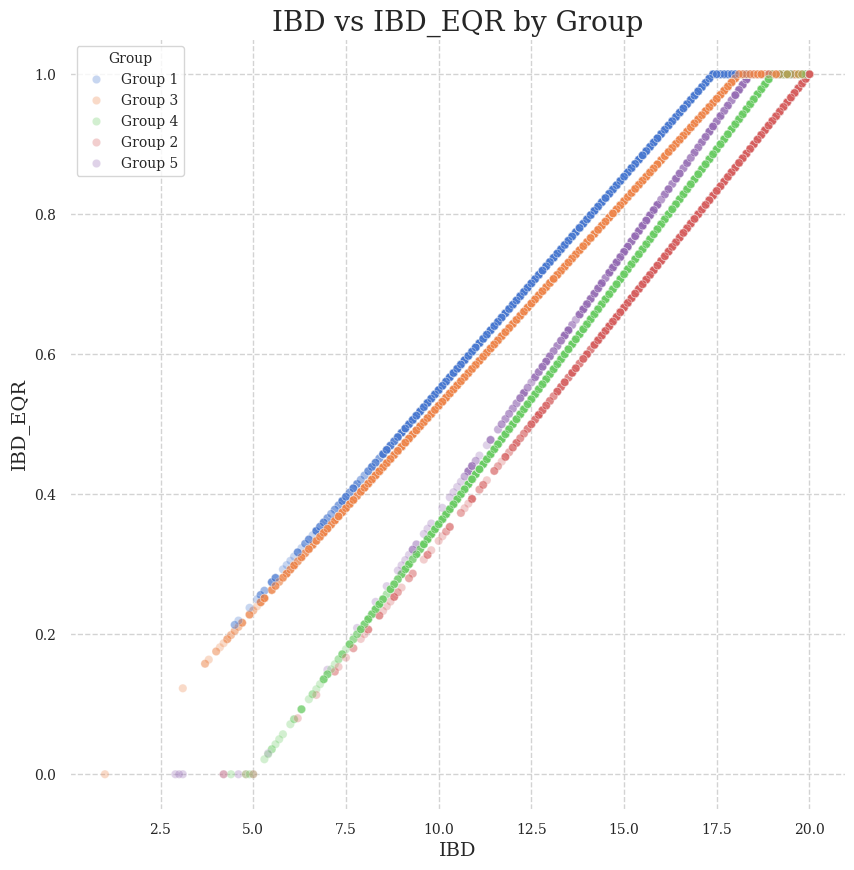

In [148]:
# PLOT THE IBD VS IBD_EQR FOR DF1
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df_copy, x='IBD', y='IBD_EQR', hue='Group', alpha=0.3)
plt.title("IBD vs IBD_EQR by Group")
plt.savefig("visualizations/Groups_IBD/IBD_vs_IBD_EQR_by_Group.png", dpi=300)
plt.show()

# Mapping

In [150]:
df_copy[df_copy["Group"] == "Group 1"]

,SamplingOperations_code,IBD,IBD_EQR,IBD_EQR_Status,CodeSite_SamplingOperations,Longitude_Lambert93,Latitude_Lambert93,Watershed,CodeDepartement,HERlvl1Code,HERlvl1Name,HERlvl2Code,HERlvl2Name,Altitude,Streamsize,Group
0,S04319000,5.2,0.256098,Bad,S04319000,249988.70,6870104.00,Loire-Bretagne,22,12,ARMORICAIN,118,MA-cotes du nord,0.0,None,Group 1
44,S02121050,11.9,0.664634,Moderate,S02121050,817346.00,6977401.00,Rhin-Meuse,08,22,ARDENNES,34,Ardennes,311.0,TP,Group 1
51,S03265993,5.5,0.274390,Bad,S03265993,378477.00,6875370.00,Seine-Normandie,50,12,ARMORICAIN,55,MA-nord est,25.0,P,Group 1
56,S03237050,13.1,0.737805,Moderate,S03237050,447196.00,6890096.00,Seine-Normandie,14,12,ARMORICAIN,55,MA-nord est,20.0,G,Group 1
71,S04024000,13.7,0.774390,Moderate,S04024000,734892.90,6636530.00,Loire-Bretagne,58,17,DEPRESSIONS SEDIMENTAIRES,52,Fosses tectoniques,0.0,TG,Group 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43354,S03240960,18.0,1.000000,High,S03240960,451220.20,6860298.28,Seine-Normandie,61,12,ARMORICAIN,55,MA-nord est,140.0,TP,Group 1
43358,S03265575,9.1,0.493902,Poor,S03265575,386277.00,6878400.00,Seine-Normandie,50,12,ARMORICAIN,55,MA-nord est,55.0,TP,Group 1
43376,S04132400,13.6,0.768293,Moderate,S04132400,429382.40,6727072.00,Loire-Bretagne,49,12,ARMORICAIN,58,MA-sud interieur,0.0,TP,Group 1
43380,S04141295,13.3,0.750000,Moderate,S04141295,411318.38,6667687.66,Loire-Bretagne,49,12,ARMORICAIN,58,MA-sud interieur,0.0,TP,Group 1


In [151]:
# for each HERlvl1Name, know the range of clasification of the IBD_EQR_Status by the IBD

# example 
# for Amoricain
# IBD range: (0, 7)   -> IBD_EQR_Status: Bad
# IBD range: (7, 12) -> IBD_EQR_Status: Poor
# IBD range: (12, 15) -> IBD_EQR_Status: Moderate
# IBD range: (15, 18) -> IBD_EQR_Status: Good
# IBD range: (18, 20) -> IBD_EQR_Status: High

status_order = ["Bad", "Poor", "Moderate", "Good", "High"]
ranges = []
groupnames = df_copy["Group"].unique()

for name in groupnames:
    print(f"Group: {name}")
    group = df_copy[df_copy["Group"] == name]
    for status in sorted(group["IBD_EQR_Status"].unique(), key=lambda x: status_order.index(x)):
        status_data = group[group["IBD_EQR_Status"] == status]
        if not status_data.empty:
            ibd_min = status_data["IBD"].min()
            ibd_max = status_data["IBD"].max()
            print(f"  IBD range: ({ibd_min}, {ibd_max}) -> IBD_EQR_Status: {status}")
            ranges.append({"Group": name, "IBD_EQR_Status": status, "IBD_min": ibd_min, "IBD_max": ibd_max})
    print("\n")

Group: Group 1
  IBD range: (4.5, 5.9) -> IBD_EQR_Status: Bad
  IBD range: (6.0, 10.0) -> IBD_EQR_Status: Poor
  IBD range: (10.1, 13.7) -> IBD_EQR_Status: Moderate
  IBD range: (13.8, 16.4) -> IBD_EQR_Status: Good
  IBD range: (16.5, 20.0) -> IBD_EQR_Status: High


Group: Group 3
  IBD range: (1.0, 6.1) -> IBD_EQR_Status: Bad
  IBD range: (6.2, 10.4) -> IBD_EQR_Status: Poor
  IBD range: (10.5, 14.3) -> IBD_EQR_Status: Moderate
  IBD range: (14.4, 17.0) -> IBD_EQR_Status: Good
  IBD range: (17.1, 20.0) -> IBD_EQR_Status: High


Group: Group 4
  IBD range: (4.4, 9.2) -> IBD_EQR_Status: Bad
  IBD range: (9.3, 12.7) -> IBD_EQR_Status: Poor
  IBD range: (12.8, 15.9) -> IBD_EQR_Status: Moderate
  IBD range: (16.0, 18.1) -> IBD_EQR_Status: Good
  IBD range: (18.2, 20.0) -> IBD_EQR_Status: High


Group: Group 2
  IBD range: (4.2, 9.3) -> IBD_EQR_Status: Bad
  IBD range: (9.6, 13.2) -> IBD_EQR_Status: Poor
  IBD range: (13.3, 16.7) -> IBD_EQR_Status: Moderate
  IBD range: (16.8, 19.0) -> IBD_E

In [152]:
ranges_df = pd.DataFrame(ranges)
ranges_df

,Group,IBD_EQR_Status,IBD_min,IBD_max
0,Group 1,Bad,4.5,5.9
1,Group 1,Poor,6.0,10.0
2,Group 1,Moderate,10.1,13.7
3,Group 1,Good,13.8,16.4
4,Group 1,High,16.5,20.0
5,Group 3,Bad,1.0,6.1
6,Group 3,Poor,6.2,10.4
7,Group 3,Moderate,10.5,14.3
8,Group 3,Good,14.4,17.0
9,Group 3,High,17.1,20.0


In [153]:
# Create a new column with the middle point of the IBD range
ranges_df["IBD_mid"] = (ranges_df["IBD_min"] + ranges_df["IBD_max"]) / 2
ranges_df

,Group,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
0,Group 1,Bad,4.5,5.9,5.20
1,Group 1,Poor,6.0,10.0,8.00
2,Group 1,Moderate,10.1,13.7,11.90
3,Group 1,Good,13.8,16.4,15.10
4,Group 1,High,16.5,20.0,18.25
5,Group 3,Bad,1.0,6.1,3.55
6,Group 3,Poor,6.2,10.4,8.30
7,Group 3,Moderate,10.5,14.3,12.40
8,Group 3,Good,14.4,17.0,15.70
9,Group 3,High,17.1,20.0,18.55


In [164]:
ranges_df.to_csv("data/processed/IBD_EQR_Status_ranges_by_GROUP_Observed.csv", index=False)

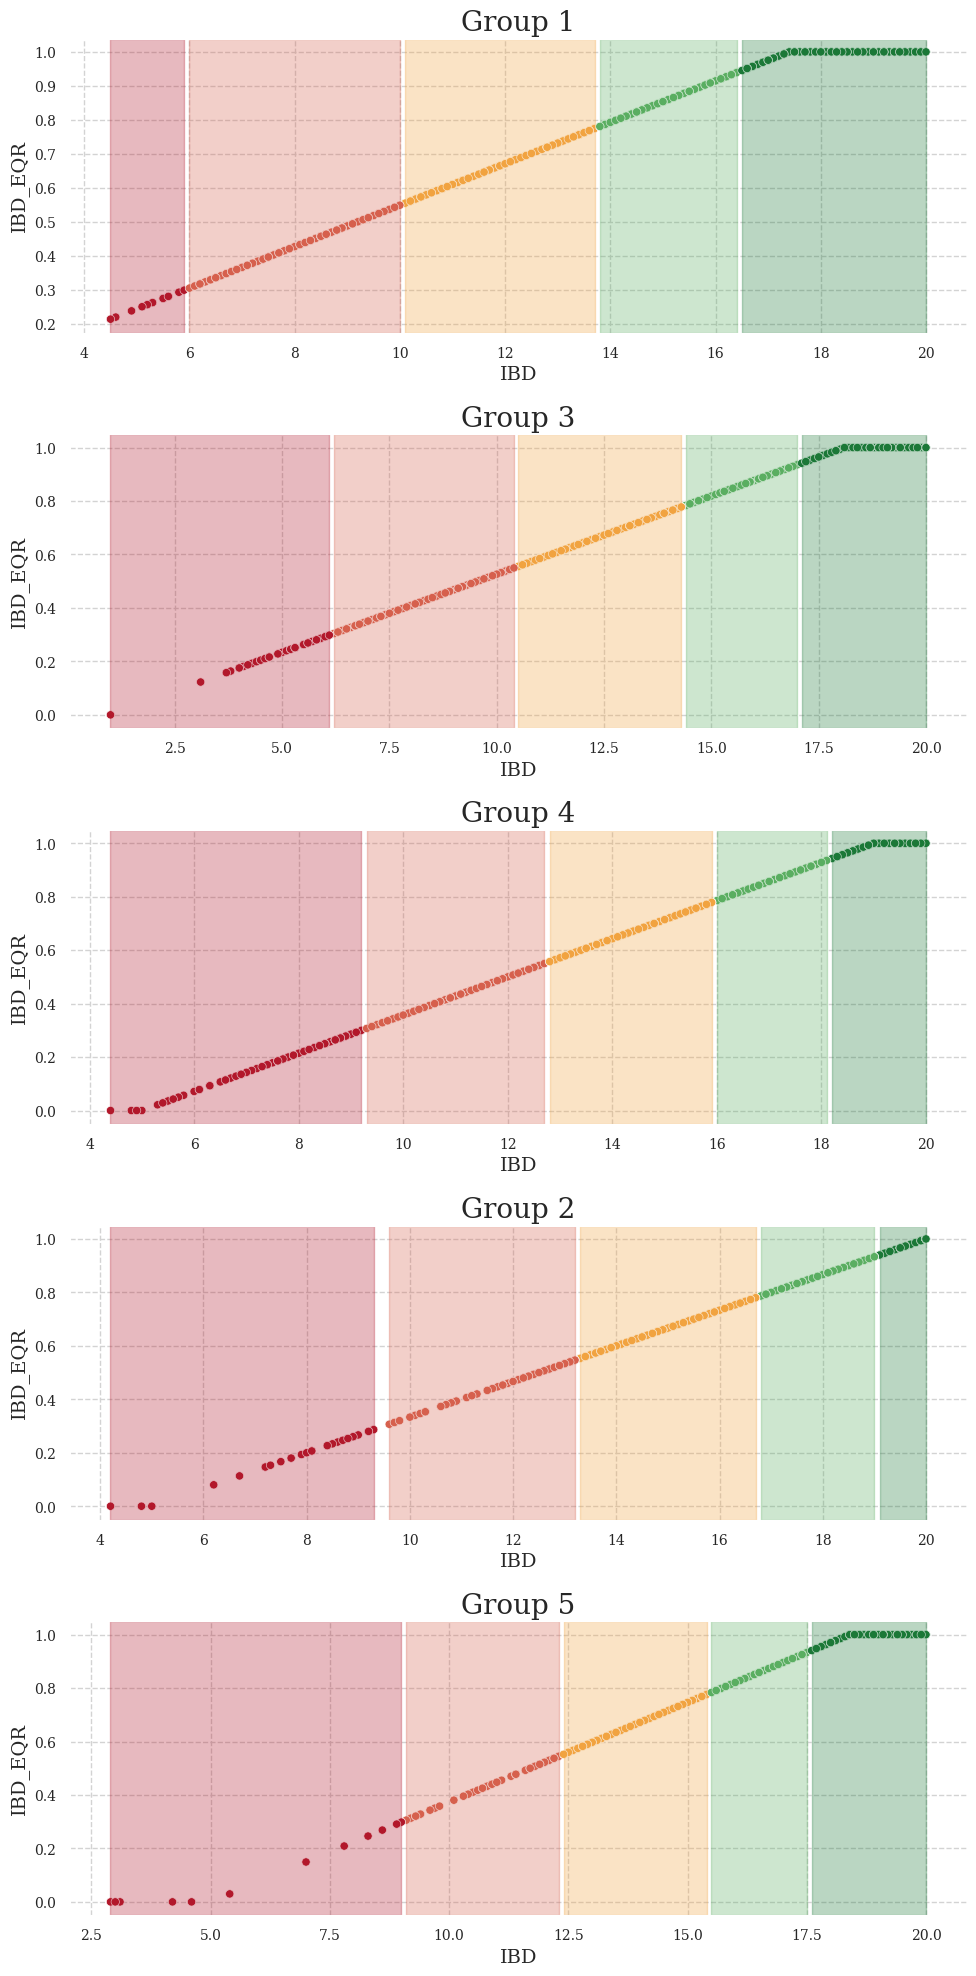

In [169]:
# Plot the regions of the IBD_min and the IBD_max for each Group and IBD_EQR_Status with the scatterplot of the IBD vs IBD_EQR of the complete ranges
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(10, 20))
for i, name in enumerate(groupnames):
    ax = axs[i]
    sns.scatterplot(data=df_copy[df_copy["Group"] == name], x='IBD', y='IBD_EQR', hue='IBD_EQR_Status', ax=ax, palette=palette)
    name_ranges = ranges_df[ranges_df["Group"] == name]
    for _, row in name_ranges.iterrows():
        ax.axvspan(row["IBD_min"], row["IBD_max"], alpha=0.3, label=row["IBD_EQR_Status"], color=palette[row["IBD_EQR_Status"]])
    ax.set_title(name)
    ax.legend_.remove()
plt.tight_layout()
plt.savefig("visualizations/Groups_IBD/IBD_vs_IBD_EQR_with_Ranges_by_Group.png", dpi=300)
plt.show()

# Making it continuous

In [178]:
import pandas as pd

order = ["Bad","Poor","Moderate","Good","High"]

def make_continuous_from_raw(df, low=0.0, high=21.0):
    out = []
    for g, t in df.groupby("Group"):
        t = t.set_index("IBD_EQR_Status").loc[order].reset_index()
        # internal boundaries from raw endpoints
        cuts = [(t.loc[i,"IBD_max"] + t.loc[i+1,"IBD_min"]) / 2 for i in range(4)]
        bounds = [(low, cuts[0]), (cuts[0], cuts[1]), (cuts[1], cuts[2]),
                  (cuts[2], cuts[3]), (cuts[3], high)]
        for (cls,(lo,hi)), mid in zip(zip(order,bounds), t["IBD_mid"]):
            out.append([g, cls, round(lo,2), round(hi,2), mid])
    return pd.DataFrame(out, columns=["Group","IBD_EQR_Status","IBD_min","IBD_max","IBD_mid"])

ranges_continuous = make_continuous_from_raw(ranges_df, low=0.0, high=21.0)
ranges_continuous

,Group,IBD_EQR_Status,IBD_min,IBD_max,IBD_mid
0,Group 1,Bad,0.00,5.95,5.20
1,Group 1,Poor,5.95,10.05,8.00
2,Group 1,Moderate,10.05,13.75,11.90
3,Group 1,Good,13.75,16.45,15.10
4,Group 1,High,16.45,21.00,18.25
5,Group 2,Bad,0.00,9.45,6.75
6,Group 2,Poor,9.45,13.25,11.40
7,Group 2,Moderate,13.25,16.75,15.00
8,Group 2,Good,16.75,19.05,17.90
9,Group 2,High,19.05,21.00,19.55


In [179]:
ranges_continuous.to_csv("data/processed/IBD_EQR_Status_ranges_by_GROUP_Continuous.csv", index=False)